# Introduction to Matplotlib

This notebook is the practical entry point into Matplotlib, but with a stronger conceptual bridge between the examples.

It combines the quick-start feel of this video notebook with selected ideas from `Kopie_von_Intro_to_matplotlib.ipynb` (werden wir hin wechseln nach Chapter 0) and `matplotlib_fundamentals_explained.ipynb` (linspace).

## What you will learn

1. The two main ways of creating plots: `pyplot` and the object-oriented (OO) interface
2. How to go from an empty `plt.plot()` call to plotting real x/y data
3. Why `fig, ax = plt.subplots()` is the default pattern we keep coming back to; ax "axes" heißt, fig für "figure" steht
4. How `np.linspace()` helps create smooth lines and well-spaced axes
4.1 The most common plot types with NumPy arrays and pandas data
5. How to customize labels, legends, ticks, limits, styles, and colors
6. How to save plots and where to go next afterwards

A short roadmap to the follow-up notebooks is included at the end.


## 0. Concepts in Matplotlib

Matplotlib is one of the core plotting libraries in the Python data ecosystem. It gives you fine-grained control over almost every visual part of a plot, which is why it is used so often in data science, research, and reporting.

### Why Matplotlib?

- It works well with Python lists, NumPy arrays, pandas Series, and DataFrames
- It scales from very quick experiments to publication-style figures
- It teaches you the plotting vocabulary used by many other libraries
- It is especially strong when you want explicit control over the figure

### ** Part 1 **: A simple workflow to keep in mind

1. Import plotting tools
2. Prepare data
3. Create a figure and one or more axes
4. Plot the data
5. Customize labels, legends, limits, and styling
6. Show or save the figure


## ** Basics ** Two ways of creating plots

Matplotlib gives us two closely related interfaces:

- `pyplot`: quick, state-based, great for getting started fast
- `OO` (object-oriented): explicit and more robust, especially when plots become more complex

We will start with `pyplot` because it makes the first examples very easy to read. Then we will switch to `fig, ax = plt.subplots()` and use that pattern as our default.

Start by importing `matplotlib.pyplot` and enabling inline output in the notebook.


In [1]:
# Import matplotlib and setup the figures to display within the notebook
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
#import seaborn

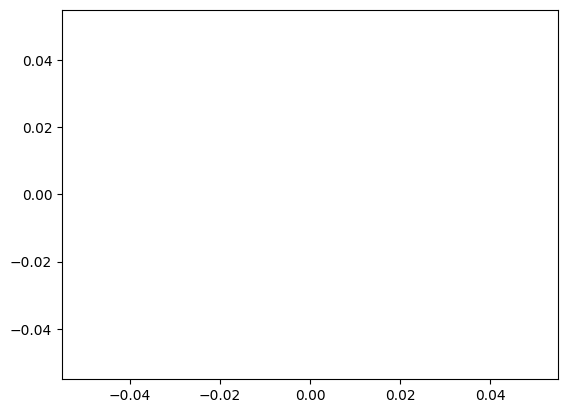

In [15]:
# Create a simple plot, without the semi-colon
plt.plot();

Without a semicolon, Jupyter prints the Python return value of `plt.plot()`, which is usually a list of `Line2D` objects.

A trailing `;` suppresses that text output. It does **not** change the figure itself, it only keeps the notebook output cleaner.


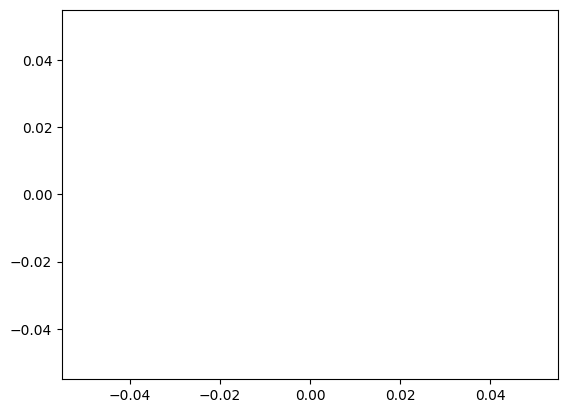

In [3]:
# With the semi-colon
plt.plot();

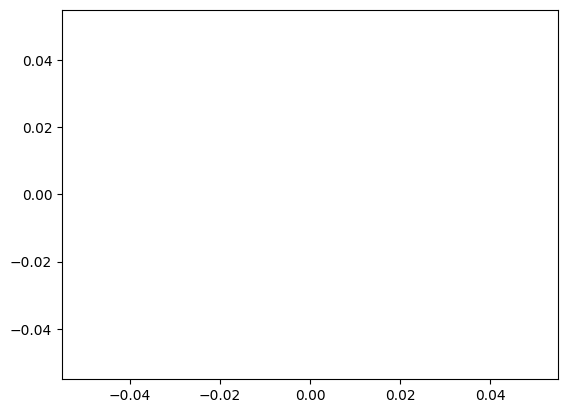

In [4]:
# You could use plt.show() if you want
plt.plot()
plt.show()

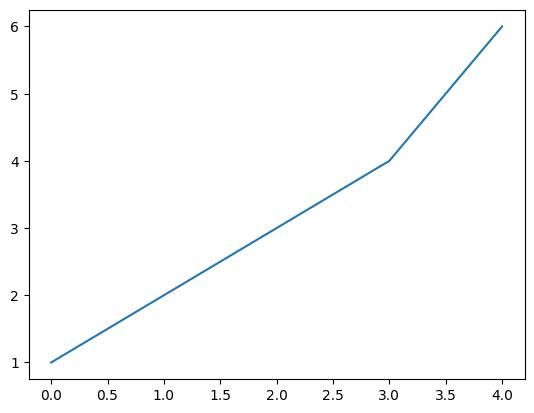

In [18]:
# Let's add some data
y=[1,2,3,4,6]
#impliziert: 
# x=[0,1,2,3,4]
plt.plot(y)
#f(x)=x Wertebereich von 1-5
#indizes in Python beginnen mit 0

In [6]:
# Create some data
x = [1, 2, 3, 4]
y = [11, 22, 33, 44]

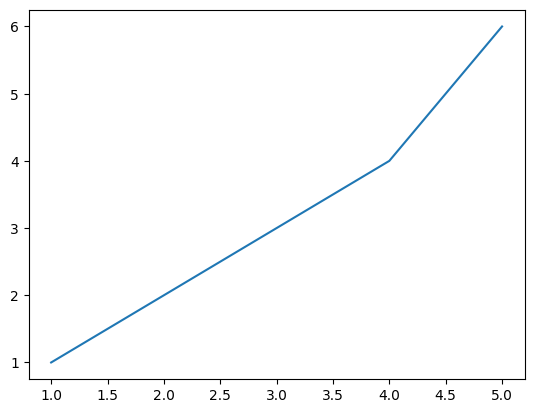

In [20]:
# With a semi-colon and now a y value
plt.plot(x, y);

In [1]:
# Creating a plot with the OO verison, confusing way first; 
# #Ihr werdet sowas vielleicht sehen, aber es ist 
# äquivalent zu fig, ax = plt.subplots() und obrigem

fig = plt.figure() # fig, ax = plt.subplots(); fig
ax = fig.add_subplot(1,1,1) # axes(chart) = ax # NICHT axis(Achse)! auseinanderhalten!
                # ncol (y indize), nrow (x indize), index
ax2 = fig.add_subplot(2,1,2)
plt.show()

NameError: name 'plt' is not defined

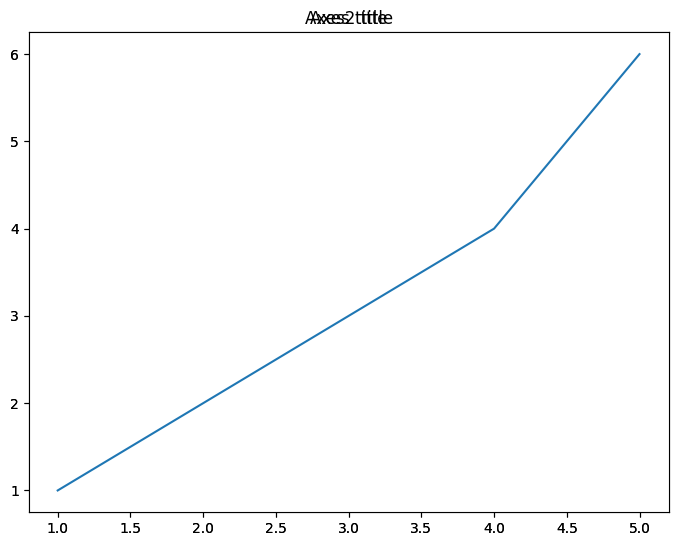

In [ ]:
# Confusing #2 - besser als #1 - das hilft aber um charts später zu überlappen 
fig = plt.figure()


ax = fig.add_axes([1,1    ,1,1])
ax.plot(x, y)
ax.set_title("Axes title")

                        
ax2 = fig.add_axes([1,1    ,1,1])
 # 4 indizes: (Richtung es platziert wird) : x, y
ax2.plot(x, y)
ax2.set_title("Axes2 title")

plt.show()

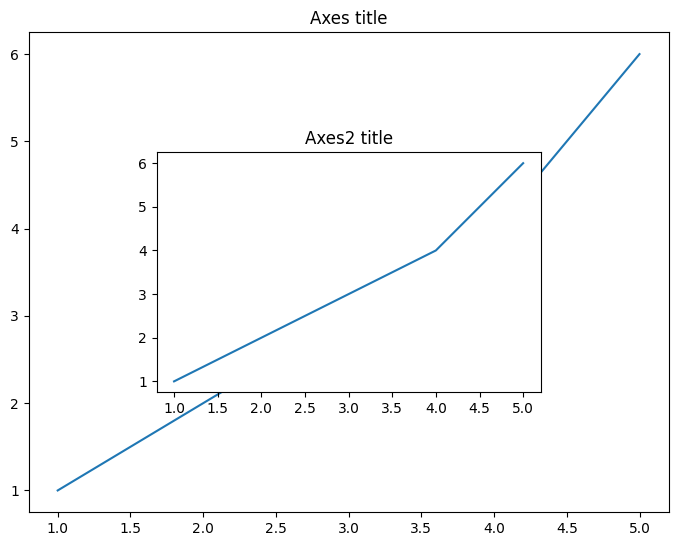

In [58]:
# Confusing #2 - besser als #1 - das hilft aber um charts später zu überlappen 
fig = plt.figure()

ax = fig.add_axes([0.8,1,         1,1])
ax.plot(x, y)
ax.set_title("Axes title")

                              #Größe der Chart zu tun
ax2 = fig.add_axes([1, 1.25,     0.6, 0.5]) # aufeinander
 # 4 indizes: (Richtung es platziert wird) : x, y,        width, height
ax2.plot(x, y)
ax2.set_title("Axes2 title")

plt.show()

--------------
# Häufigste Weg um Axes/Charts zu definieren

Axes(0.125,0.11;0.775x0.77)


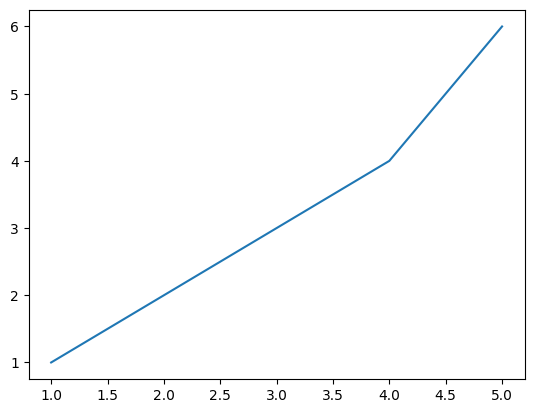

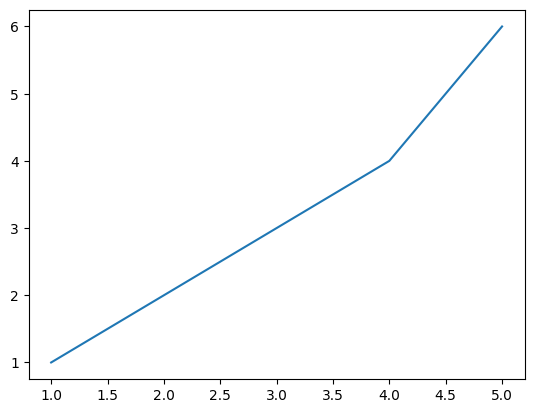

In [53]:
# Easier and more robust going forward (what we're going to use) # Standard
fig, ax = plt.subplots(1,1) #plot = figure ; charts = axes
#ax = fit.add_subplot(1,1,1), nicht gemacht
ax.plot(x, y);
print(ax)

# How to draw 2 scatteplots in different panels
fig, ax2 = plt.subplots()
ax2.plot(x, y);

### How to draw 2 scatterplots in different panels

Let's understand figure and axes in a little more detail before looking at the full figure anatomy.

Suppose we want to draw two sets of points side-by-side instead of in the same plotting area.

You can do that by creating two separate subplots, or **Axes**, with `plt.subplots(1, 2)`. This means:

1. one row
2. two subplot areas

The command returns two things:

1. the **figure**
2. the **axes** inside that figure

![](https://www.machinelearningplus.com/wp-content/uploads/2019/01/99_matplotlib_structure-1.png)

Previously, when we called `plt.plot()`, Matplotlib used the current default axes. But once we create multiple axes explicitly, we need to draw on the **specific** axes we want.


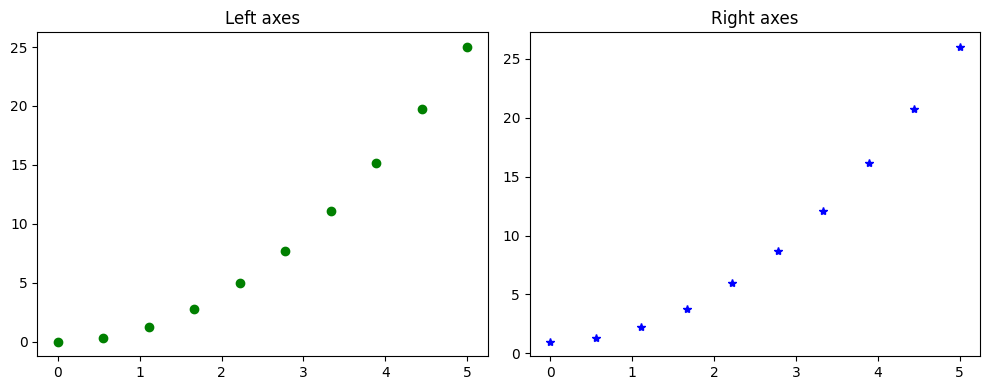

In [ ]:
# Two panels side-by-side
x_panel = np.linspace(0, 5, 10)
y_panel = x_panel ** 2

fig, axes = plt.subplots(1, 2)#, figsize=(10, 4))
                      #ncol, nrow
ax1 = axes[0]
ax2 = axes[1]

#ax1.plot(x_panel, y_panel, 'og')
#ax1.set_title('Left axes')

#ax2.plot(x_panel, y_panel + 1, '*b')
ax2.set_title('Right axes')

#plt.tight_layout()
plt.show()


# ** SWITCH NOTEBOOK to Kopie_ ** then continue

The first version is explicit and beginner-friendly because you can clearly see which plot goes to which axes.

Once that feels natural, we can write the same idea more compactly.


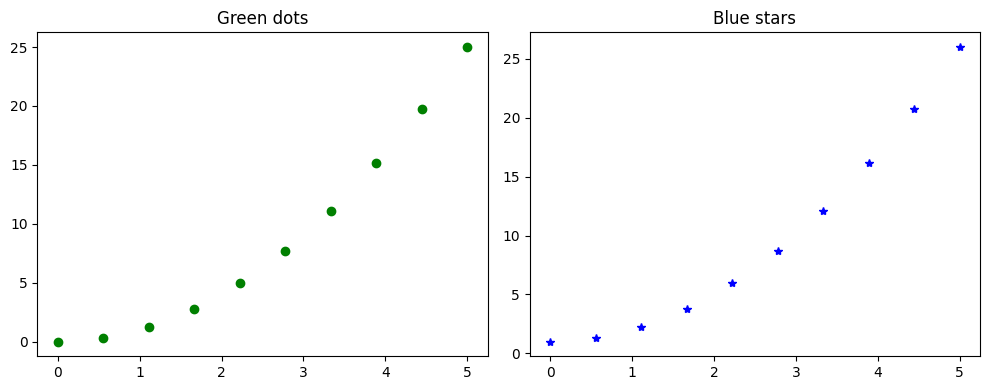

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_values, fmt, title in zip(
    axes,
    [y_panel, y_panel + 1],
    ['og', '*b'],
    ['Green dots', 'Blue stars']
):
    ax.plot(x_panel, y_values, fmt)
    ax.set_title(title)

plt.tight_layout()
plt.show()


### Figure anatomy: Figure, Axes, Axis, Artists

After seeing two side-by-side panels, the anatomy of a Matplotlib figure becomes easier to read.

![](https://matplotlib.org/stable/_images/anatomy.png)

A few definitions are worth locking in early:

- **Figure**: the full canvas or container
- **Axes**: one plotting area inside the figure
- **Axis**: the number line that creates ticks and tick labels
- **Artists**: everything visible, such as lines, points, text, legends, and titles

This is why `fig, ax = plt.subplots()` is such an important line:

- `fig` gives you control over the whole canvas
- `ax` gives you control over one plot region

In notebooks and scripts, prefer `plt.show()` rather than `fig.show()`. `plt.show()` is the standard display function and manages all open figures more reliably.


In [13]:
# This is where the object orientated name comes from 
type(fig), type(ax)

(matplotlib.figure.Figure, matplotlib.axes._axes.Axes)

FileNotFoundError: [Errno 2] No such file or directory: '../images/simple-plot.png'

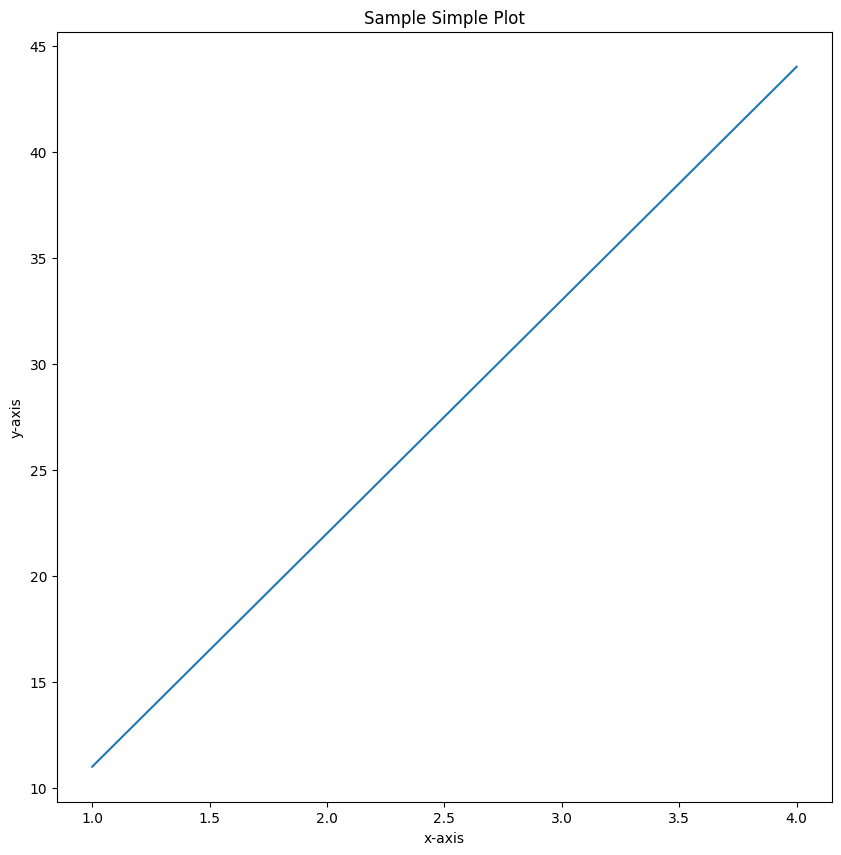

In [14]:
# A matplotlib workflow

# 0. Import and get matplotlib ready
%matplotlib inline
import matplotlib.pyplot as plt

# 1. Prepare data
x = [1, 2, 3, 4]
y = [11, 22, 33, 44]

# 2. Setup plot
fig, ax = plt.subplots(figsize=(10,10))

# 3. Plot data
ax.plot(x, y)

# 4. Customize plot
ax.set(title="Sample Simple Plot", xlabel="x-axis", ylabel="y-axis")

# 5. Save & show
fig.savefig("../images/simple-plot.png")

## ** 2nd Part **: Making the most common type of plots using NumPy arrays

Matplotlib works especially well with numeric arrays. Before we plot lines, scatter plots, bars, and histograms, we need one small but powerful tool: `np.linspace()`.

We will use this section to connect several beginner ideas that belong together:

- `np.linspace()` for generating evenly spaced x-values
- arrays vs. lists vs. pandas objects
- line and scatter plots with both `pyplot` and the OO interface
- bar charts, histograms, and subplots


In [ ]:
import numpy as np

### Deep dive into `np.linspace()`

`np.linspace(start, stop, num)` creates `num` evenly spaced values between `start` and `stop`.

That matters for plotting because:

- a few points give you a rough sketch
- many points give you a smooth-looking curve
- evenly spaced points are also useful when you want evenly spaced ticks later on


5 evenly spaced points:
[ 0.   2.5  5.   7.5 10. ]

100 evenly spaced points (first 10 shown):
[0.         0.1010101  0.2020202  0.3030303  0.4040404  0.50505051
 0.60606061 0.70707071 0.80808081 0.90909091]


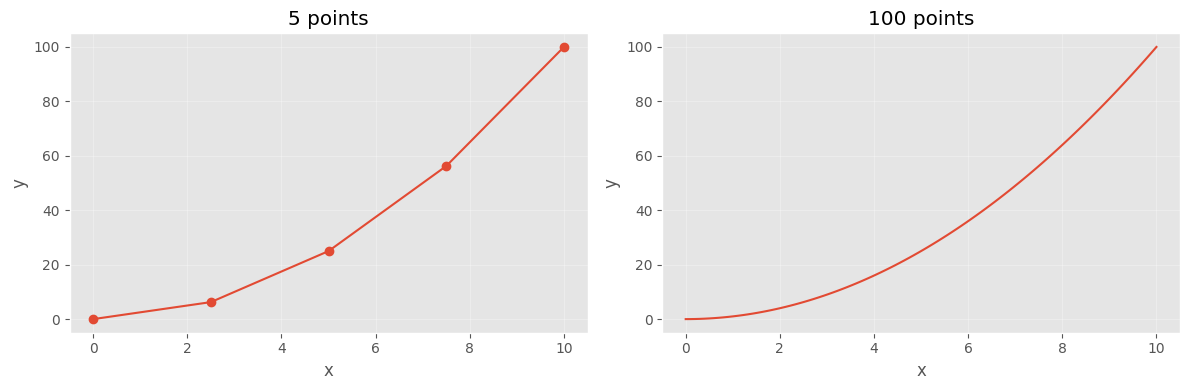

In [ ]:
# A few points vs. many points
x_few = np.linspace(0, 10, 5)
x_many = np.linspace(0, 10, 100)

print('5 evenly spaced points:')
print(x_few)
print('\n100 evenly spaced points (first 10 shown):')
print(x_many[:10])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_few, x_few**2, 'o-')
axes[0].set_title('5 points')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_many, x_many**2)
axes[1].set_title('100 points')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Arrays vs. lists vs. pandas objects

Matplotlib can plot all three, but they behave differently:

- Python lists are flexible and beginner-friendly
- NumPy arrays are best for numeric computations and vectorized operations
- pandas objects are convenient when your data already lives in a table

For plotting workflows, NumPy arrays and pandas objects usually make life easier than plain lists.


In [ ]:
import pandas as pd

python_list = [1, 2, 3, 4]
numpy_array = np.array([1, 2, 3, 4])
pandas_series = pd.Series([1, 2, 3, 4], name='values')

print('Python list * 2 -> duplicates the list:')
print(python_list * 2)
print('\nNumPy array * 2 -> multiplies elementwise:')
print(numpy_array * 2)
print('\npandas Series * 2 -> also multiplies elementwise:')
print(pandas_series * 2)


Python list * 2 -> duplicates the list:
[1, 2, 3, 4, 1, 2, 3, 4]

NumPy array * 2 -> multiplies elementwise:
[2 4 6 8]

pandas Series * 2 -> also multiplies elementwise:
0    2
1    4
2    6
3    8
Name: values, dtype: int64


### Line

Line is the default type of visualization in Matplotlib. Usually, unless specified otherwise, your plots will start out as lines.

In [ ]:
# Create an array
x = np.linspace(0, 10, 100)
x[:10]

array([0.        , 0.1010101 , 0.2020202 , 0.3030303 , 0.4040404 ,
       0.50505051, 0.60606061, 0.70707071, 0.80808081, 0.90909091])

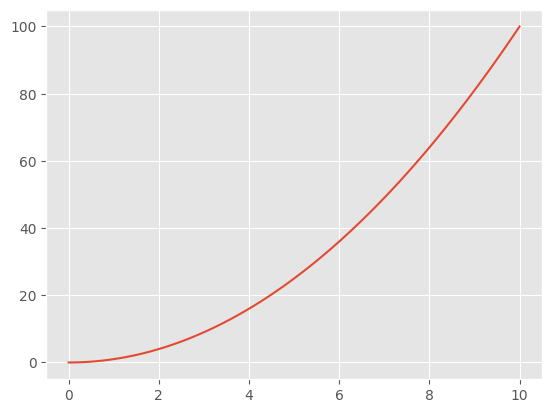

In [ ]:
# The default plot is line
fig, ax = plt.subplots()
ax.plot(x, x**2);

### Scatter

Before drawing a true scatter plot, it helps to notice something important: `plt.plot()` draws a **line chart by default** if you only pass one sequence of values.


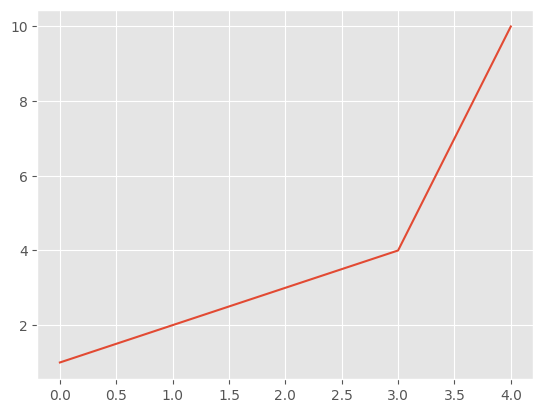

In [ ]:
plt.plot([1, 2, 3, 4, 10]);


Matplotlib interprets that as y-values and automatically uses index positions for x-values.

To control the appearance more precisely, `plt.plot()` can take three basic inputs in this order:

`plt.plot(x, y, format)`

The optional `format` string is shorthand for a combination of marker, line style, and color.

Common examples:

- `'og'` = green circles, no connecting line
- `'*b'` = blue stars, no connecting line
- `'o-g'` = green circles with a solid line
- `'--r'` = red dashed line


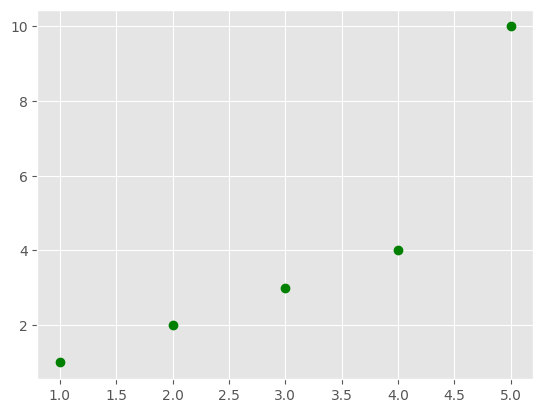

In [ ]:
# A real scatter-like point display using format strings
plt.plot([1, 2, 3, 4, 5], [1, 2, 3, 4, 10], 'og')
plt.show()


Now let's add a second set of points to the **same axes**. This is an important moment conceptually: calling `plt.plot()` again does **not** create a new panel. It adds more marks to the current plotting area.


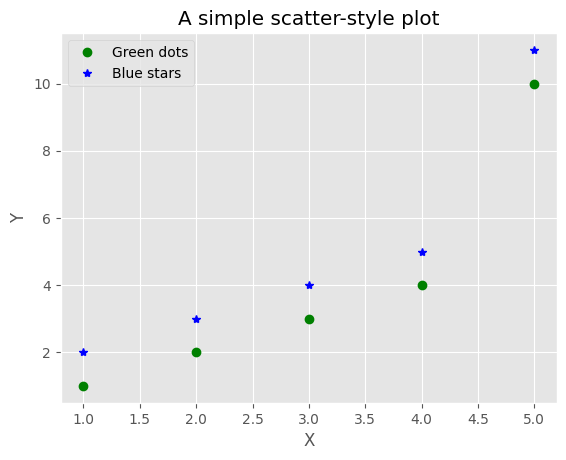

In [ ]:
xx = np.array([1, 2, 3, 4, 5])
yy = np.array([1, 2, 3, 4, 10])

plt.plot(xx, yy, 'og', label='Green dots')
plt.plot(xx, yy + 1, '*b', label='Blue stars')
plt.title('A simple scatter-style plot')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(loc='best')
plt.show()


We can also make the same plot larger and control the visible axis range.


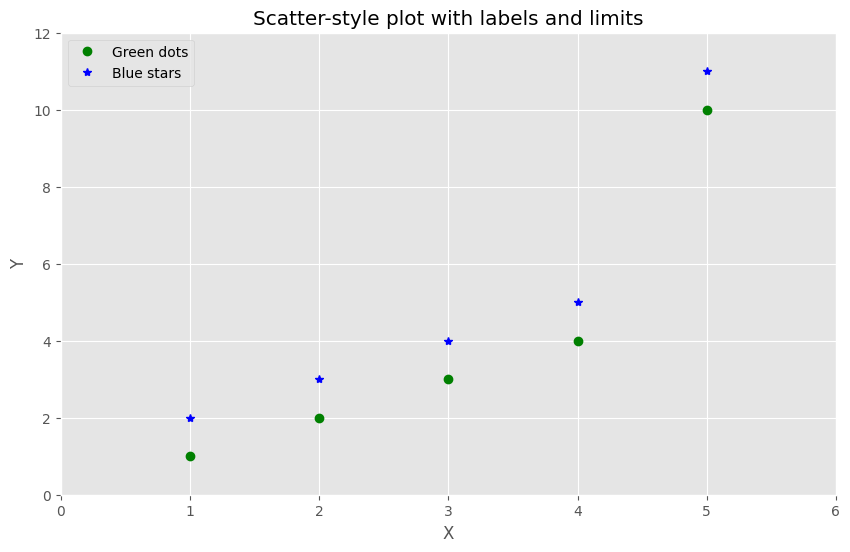

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(xx, yy, 'og', label='Green dots')
plt.plot(xx, yy + 1, '*b', label='Blue stars')
plt.xlim(0, 6)
plt.ylim(0, 12)
plt.title('Scatter-style plot with labels and limits')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(loc='best')
plt.show()


The same idea becomes more explicit in the OO interface. This is the version to prefer once you are doing anything beyond a quick one-liner.


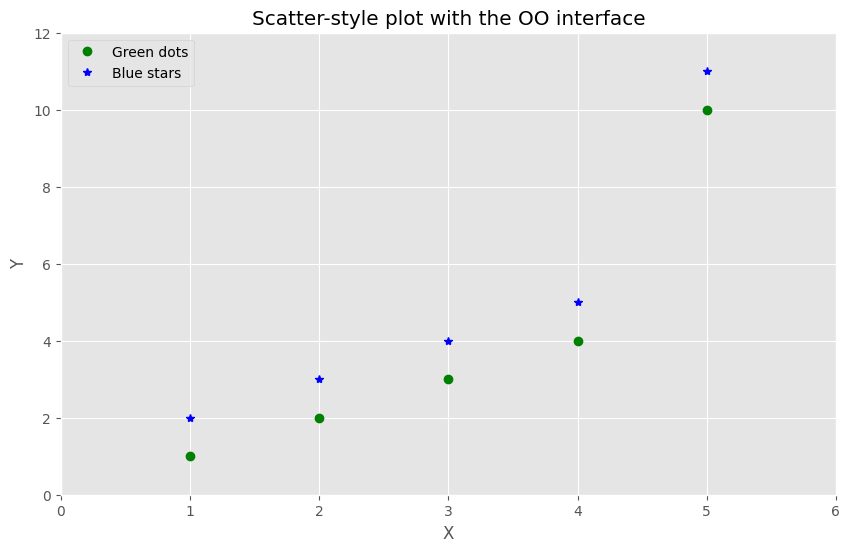

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(xx, yy, 'og', label='Green dots')
ax.plot(xx, yy + 1, '*b', label='Blue stars')
ax.set_xlim(0, 6)
ax.set_ylim(0, 12)
ax.set_title('Scatter-style plot with the OO interface')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend(loc='best')
plt.show()


If you want a dedicated scatter API instead of marker-only `plot()` calls, use `plt.scatter(...)` or `ax.scatter(...)`.


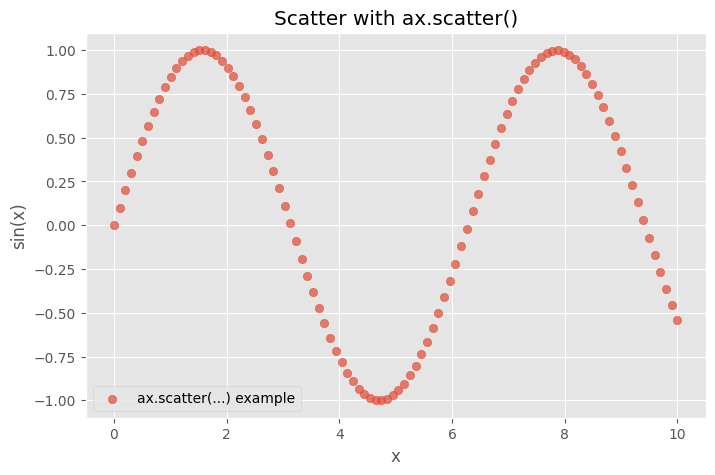

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, np.sin(x), alpha=0.7, label='ax.scatter(...) example')
ax.set_title('Scatter with ax.scatter()')
ax.set_xlabel('x')
ax.set_ylabel('sin(x)')
ax.legend(loc='best')
plt.show()


### Bar
* Vertical
* Horizontal

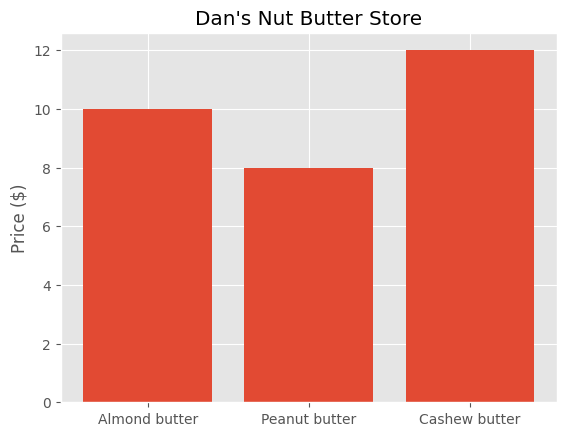

In [ ]:
# You can make plots from a dictionary
nut_butter_prices = {"Almond butter": 10,
                     "Peanut butter": 8,
                     "Cashew butter": 12}
fig, ax = plt.subplots()
ax.bar(nut_butter_prices.keys(), nut_butter_prices.values())
ax.set(title="Dan's Nut Butter Store", ylabel="Price ($)");

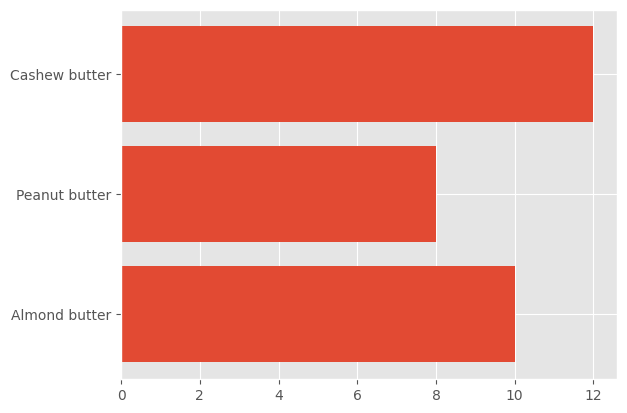

In [ ]:
fig, ax = plt.subplots()
ax.barh(list(nut_butter_prices.keys()), list(nut_butter_prices.values()));

### Histogram (hist)

* Could show image of normal distribution here

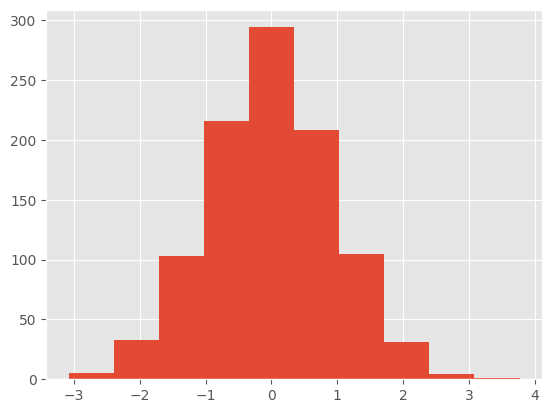

In [ ]:
# Make some data from a normal distribution
x = np.random.randn(1000) # pulls data from a normal distribution

fig, ax = plt.subplots()
ax.hist(x);

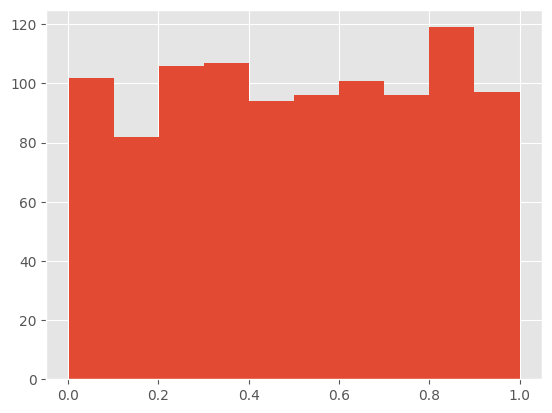

In [ ]:
x = np.random.random(1000) # random data from random distribution

fig, ax = plt.subplots()
ax.hist(x);

### Subplots

Subplots are multiple plotting areas inside one figure.

Before the larger grid examples, it helps to see the most common beginner version first: two panels side by side. This is where the OO pattern becomes especially useful because each panel gets its own `ax` object.


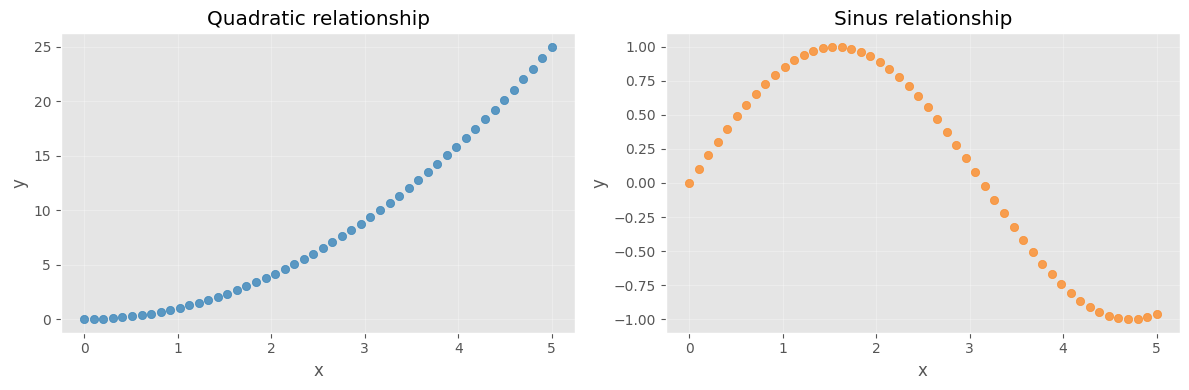

In [ ]:
# Two scatterplots in different panels
x_panel = np.linspace(0, 5, 50)
y_panel_1 = x_panel**2
y_panel_2 = np.sin(x_panel)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(x_panel, y_panel_1, color='tab:blue', alpha=0.7)
axes[0].set_title('Quadratic relationship')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(x_panel, y_panel_2, color='tab:orange', alpha=0.7)
axes[1].set_title('Sinus relationship')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


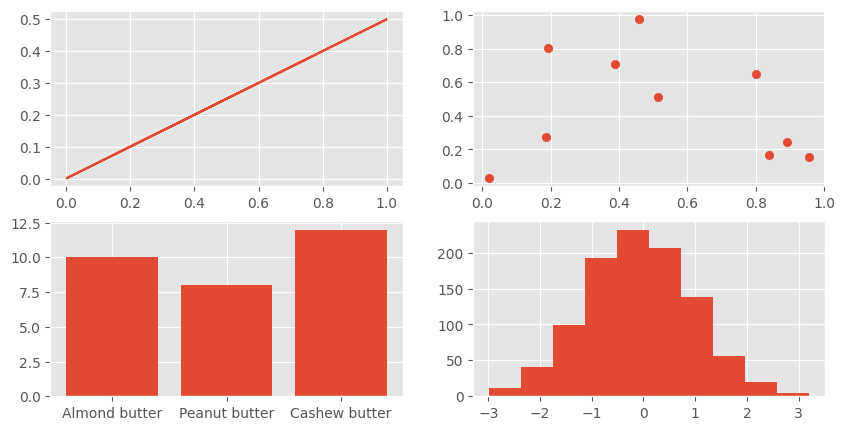

In [ ]:
# Option 1: Create multiple subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, 
                                             ncols=2, 
                                             figsize=(10, 5))

# Plot data to each axis
ax1.plot(x, x/2);
ax2.scatter(np.random.random(10), np.random.random(10));
ax3.bar(nut_butter_prices.keys(), nut_butter_prices.values());
ax4.hist(np.random.randn(1000));

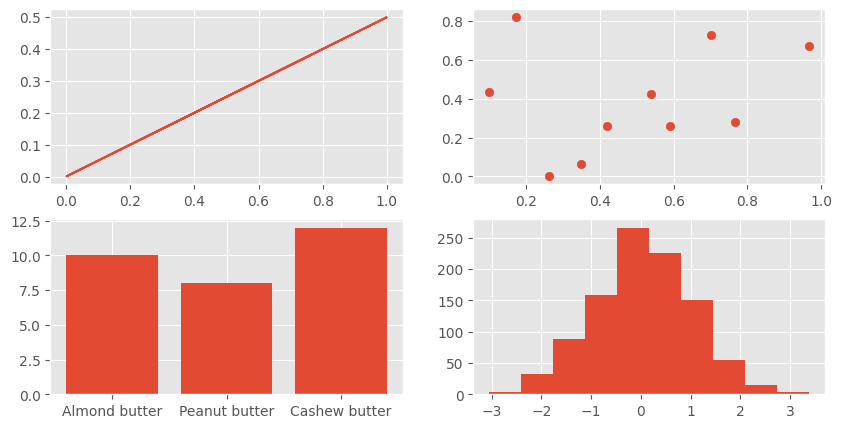

In [ ]:
# Option 2: Create multiple subplots
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 5))

# Index to plot data
ax[0, 0].plot(x, x/2);
ax[0, 1].scatter(np.random.random(10), np.random.random(10));
ax[1, 0].bar(nut_butter_prices.keys(), nut_butter_prices.values());
ax[1, 1].hist(np.random.randn(1000));

## 3. Plotting data directly with pandas
This section uses the pandas `pd.plot()` method on a DataFrame to plot columns directly.

* https://datatofish.com/plot-dataframe-pandas/
* https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html

* `line`
* `scatter`
* `bar`
* `hist`
* `df.plot(subplots=True, figsize=(6, 6))`

To plot data with pandas, we first have to import it as `pd`.

In [ ]:
import pandas as pd

Now we need some data to check out.

In [ ]:
# Let's import the car_sales dataset
car_sales = pd.read_csv("../data/car-sales.csv")
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,"$4,000.00"
1,Honda,Red,87899,4,"$5,000.00"
2,Toyota,Blue,32549,3,"$7,000.00"
3,BMW,Black,11179,5,"$22,000.00"
4,Nissan,White,213095,4,"$3,500.00"
5,Toyota,Green,99213,4,"$4,500.00"
6,Honda,Blue,45698,4,"$7,500.00"
7,Honda,Blue,54738,4,"$7,000.00"
8,Toyota,White,60000,4,"$6,250.00"
9,Nissan,White,31600,4,"$9,700.00"


### Line
* Concept
* DataFrame

Often, reading things won't make sense. Practice writing code for yourself, get it out of the docs and into your workspace. See what happens when you run it.

Let's start with trying to replicate the pandas visualization documents.

In [ ]:
# Start with some dummy data
ts = pd.Series(np.random.randn(1000),
               index=pd.date_range('1/1/2020', periods=1000))
ts

2020-01-01    1.433403
2020-01-02   -2.287721
2020-01-03   -0.104948
2020-01-04    0.789054
2020-01-05   -0.474264
                ...   
2022-09-22    0.260583
2022-09-23   -0.205302
2022-09-24   -0.934851
2022-09-25    0.066871
2022-09-26    0.293206
Freq: D, Length: 1000, dtype: float64

In [ ]:
# What does cumsum() do?
ts.cumsum()

2020-01-01    1.433403
2020-01-02   -0.854318
2020-01-03   -0.959267
2020-01-04   -0.170213
2020-01-05   -0.644477
                ...   
2022-09-22    6.882020
2022-09-23    6.676718
2022-09-24    5.741867
2022-09-25    5.808738
2022-09-26    6.101944
Freq: D, Length: 1000, dtype: float64

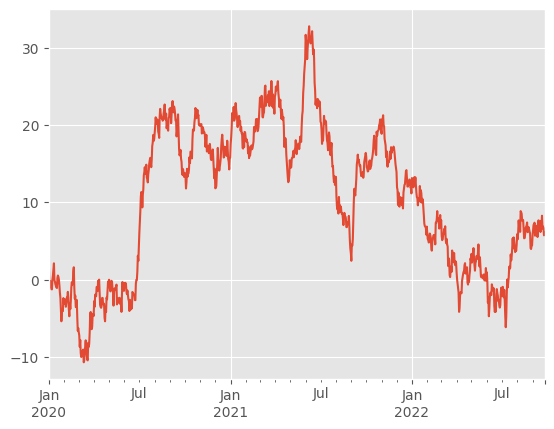

In [ ]:
ts.cumsum().plot();

### Working with actual data

Let's do a little data manipulation on our `car_sales` DataFrame.

In [ ]:
# Remove price column symbols
car_sales["Price"] = car_sales["Price"].str.replace(r'[\$,.]', '', regex=True)
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,400000
1,Honda,Red,87899,4,500000
2,Toyota,Blue,32549,3,700000
3,BMW,Black,11179,5,2200000
4,Nissan,White,213095,4,350000
5,Toyota,Green,99213,4,450000
6,Honda,Blue,45698,4,750000
7,Honda,Blue,54738,4,700000
8,Toyota,White,60000,4,625000
9,Nissan,White,31600,4,970000


In [ ]:
# Remove last two zeros
car_sales["Price"] = car_sales["Price"].str[:-2]
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,4000
1,Honda,Red,87899,4,5000
2,Toyota,Blue,32549,3,7000
3,BMW,Black,11179,5,22000
4,Nissan,White,213095,4,3500
5,Toyota,Green,99213,4,4500
6,Honda,Blue,45698,4,7500
7,Honda,Blue,54738,4,7000
8,Toyota,White,60000,4,6250
9,Nissan,White,31600,4,9700


In [ ]:
# Add a date column
car_sales["Sale Date"] = pd.date_range("1/1/2020", periods=len(car_sales))
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Sale Date
0,Toyota,White,150043,4,4000,2020-01-01
1,Honda,Red,87899,4,5000,2020-01-02
2,Toyota,Blue,32549,3,7000,2020-01-03
3,BMW,Black,11179,5,22000,2020-01-04
4,Nissan,White,213095,4,3500,2020-01-05
5,Toyota,Green,99213,4,4500,2020-01-06
6,Honda,Blue,45698,4,7500,2020-01-07
7,Honda,Blue,54738,4,7000,2020-01-08
8,Toyota,White,60000,4,6250,2020-01-09
9,Nissan,White,31600,4,9700,2020-01-10


In [ ]:
# Make total sales column (doesn't work, adds as string)
#car_sales["Total Sales"] = car_sales["Price"].cumsum()

# Oops... want them as int's not string
car_sales["Total Sales"] = car_sales["Price"].astype(int).cumsum()
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Sale Date,Total Sales
0,Toyota,White,150043,4,4000,2020-01-01,4000
1,Honda,Red,87899,4,5000,2020-01-02,9000
2,Toyota,Blue,32549,3,7000,2020-01-03,16000
3,BMW,Black,11179,5,22000,2020-01-04,38000
4,Nissan,White,213095,4,3500,2020-01-05,41500
5,Toyota,Green,99213,4,4500,2020-01-06,46000
6,Honda,Blue,45698,4,7500,2020-01-07,53500
7,Honda,Blue,54738,4,7000,2020-01-08,60500
8,Toyota,White,60000,4,6250,2020-01-09,66750
9,Nissan,White,31600,4,9700,2020-01-10,76450


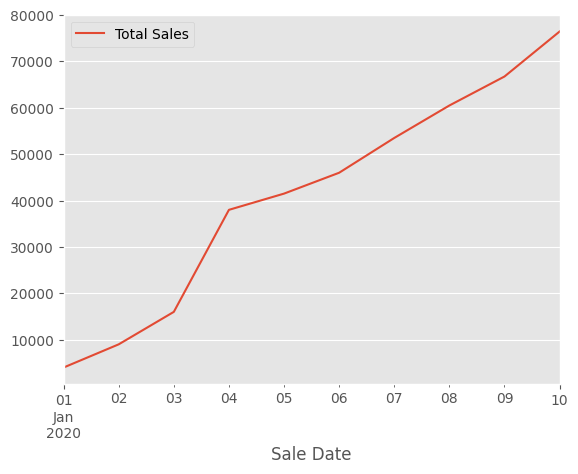

In [ ]:
car_sales.plot(x='Sale Date', y='Total Sales');

### Scatter
* Concept
* DataFrame

<Axes: xlabel='Odometer (KM)', ylabel='Price'>

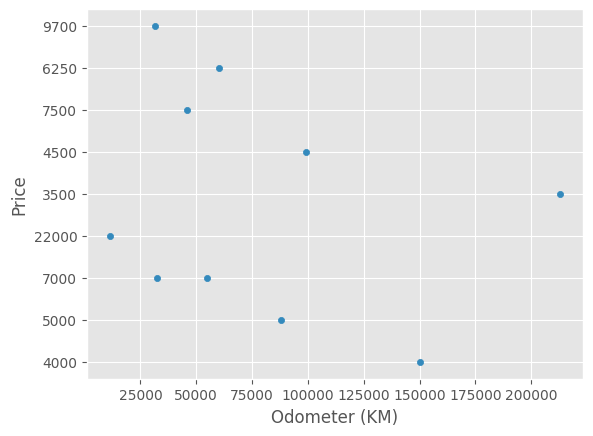

In [ ]:
# Doesn't work
car_sales.plot(x="Odometer (KM)", y="Price", kind="scatter")

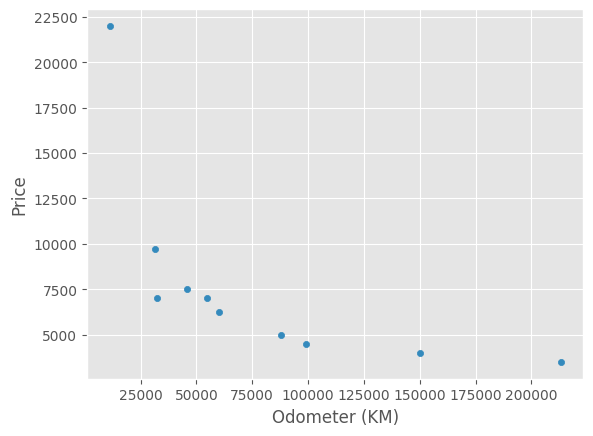

In [ ]:
# Convert Price to int
car_sales["Price"] = car_sales["Price"].astype(int)
car_sales.plot(x="Odometer (KM)", y="Price", kind='scatter');

### Bar
* Concept
* DataFrame

In [ ]:
x = np.random.rand(10, 4)
x

array([[0.08056699, 0.91995933, 0.30385586, 0.40177198],
       [0.9592281 , 0.93082788, 0.91422341, 0.84301816],
       [0.00512231, 0.06640123, 0.19771499, 0.47360184],
       [0.89177203, 0.09091725, 0.59630936, 0.89263612],
       [0.49299654, 0.84898008, 0.88929123, 0.50652439],
       [0.13558336, 0.66702251, 0.89863579, 0.49914709],
       [0.15840901, 0.6995962 , 0.985987  , 0.94052248],
       [0.05930841, 0.38773719, 0.7569775 , 0.98970981],
       [0.27614183, 0.09536594, 0.07283022, 0.79293162],
       [0.53039624, 0.91560387, 0.21198639, 0.51667918]])

In [ ]:
df = pd.DataFrame(x, columns=['a', 'b', 'c', 'd'])
df

,a,b,c,d
0,0.080567,0.919959,0.303856,0.401772
1,0.959228,0.930828,0.914223,0.843018
2,0.005122,0.066401,0.197715,0.473602
3,0.891772,0.090917,0.596309,0.892636
4,0.492997,0.848980,0.889291,0.506524
5,0.135583,0.667023,0.898636,0.499147
6,0.158409,0.699596,0.985987,0.940522
7,0.059308,0.387737,0.756977,0.989710
8,0.276142,0.095366,0.072830,0.792932
9,0.530396,0.915604,0.211986,0.516679


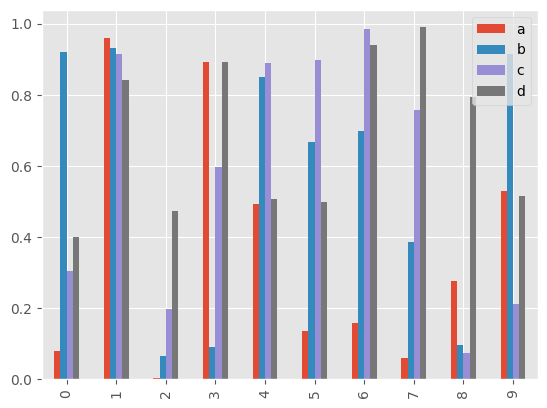

In [ ]:
df.plot.bar();

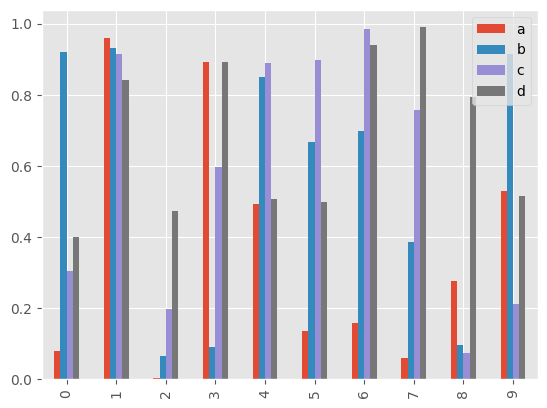

In [ ]:
# Can do the same thing with 'kind' keyword
df.plot(kind='bar');

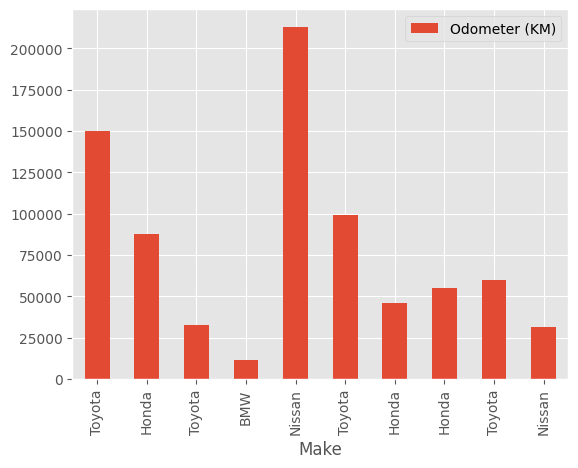

In [ ]:
car_sales.plot(x='Make', y='Odometer (KM)', kind='bar');

### Histograms


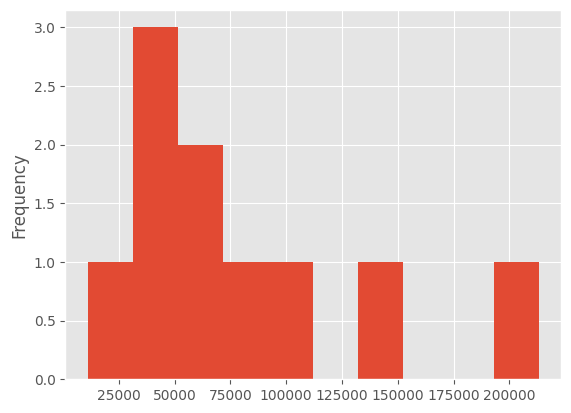

In [ ]:
car_sales["Odometer (KM)"].plot.hist();

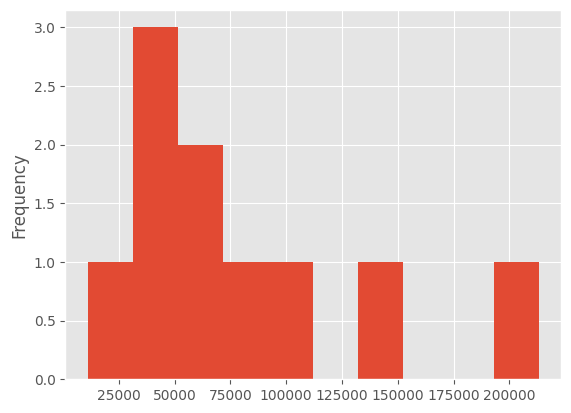

In [ ]:
car_sales["Odometer (KM)"].plot(kind="hist");

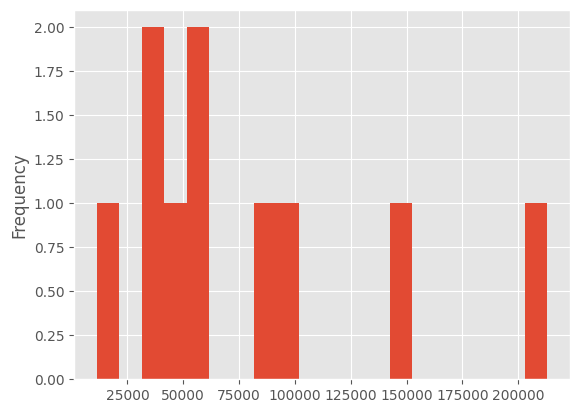

In [ ]:
# Default number of bins is 10 
car_sales["Odometer (KM)"].plot.hist(bins=20);

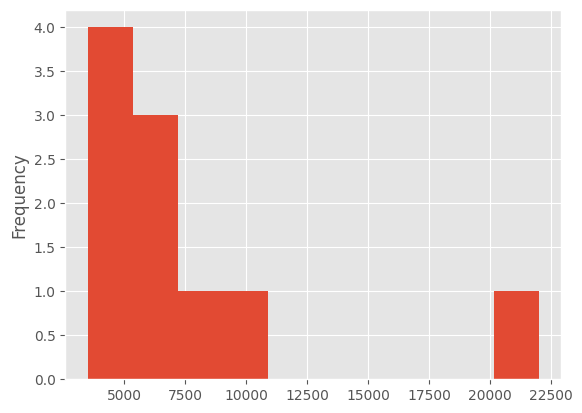

In [ ]:
car_sales["Price"].plot.hist(bins=10);

## **3rd Part ** Example:

In [ ]:
# Let's try with another dataset
heart_disease = pd.read_csv("../data/heart-disease.csv")
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


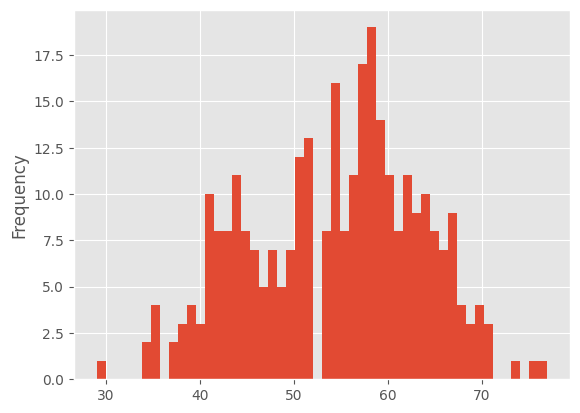

In [ ]:
heart_disease["age"].plot.hist(bins=50);

### Subplots
* Concept
* DataFrame

In [ ]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


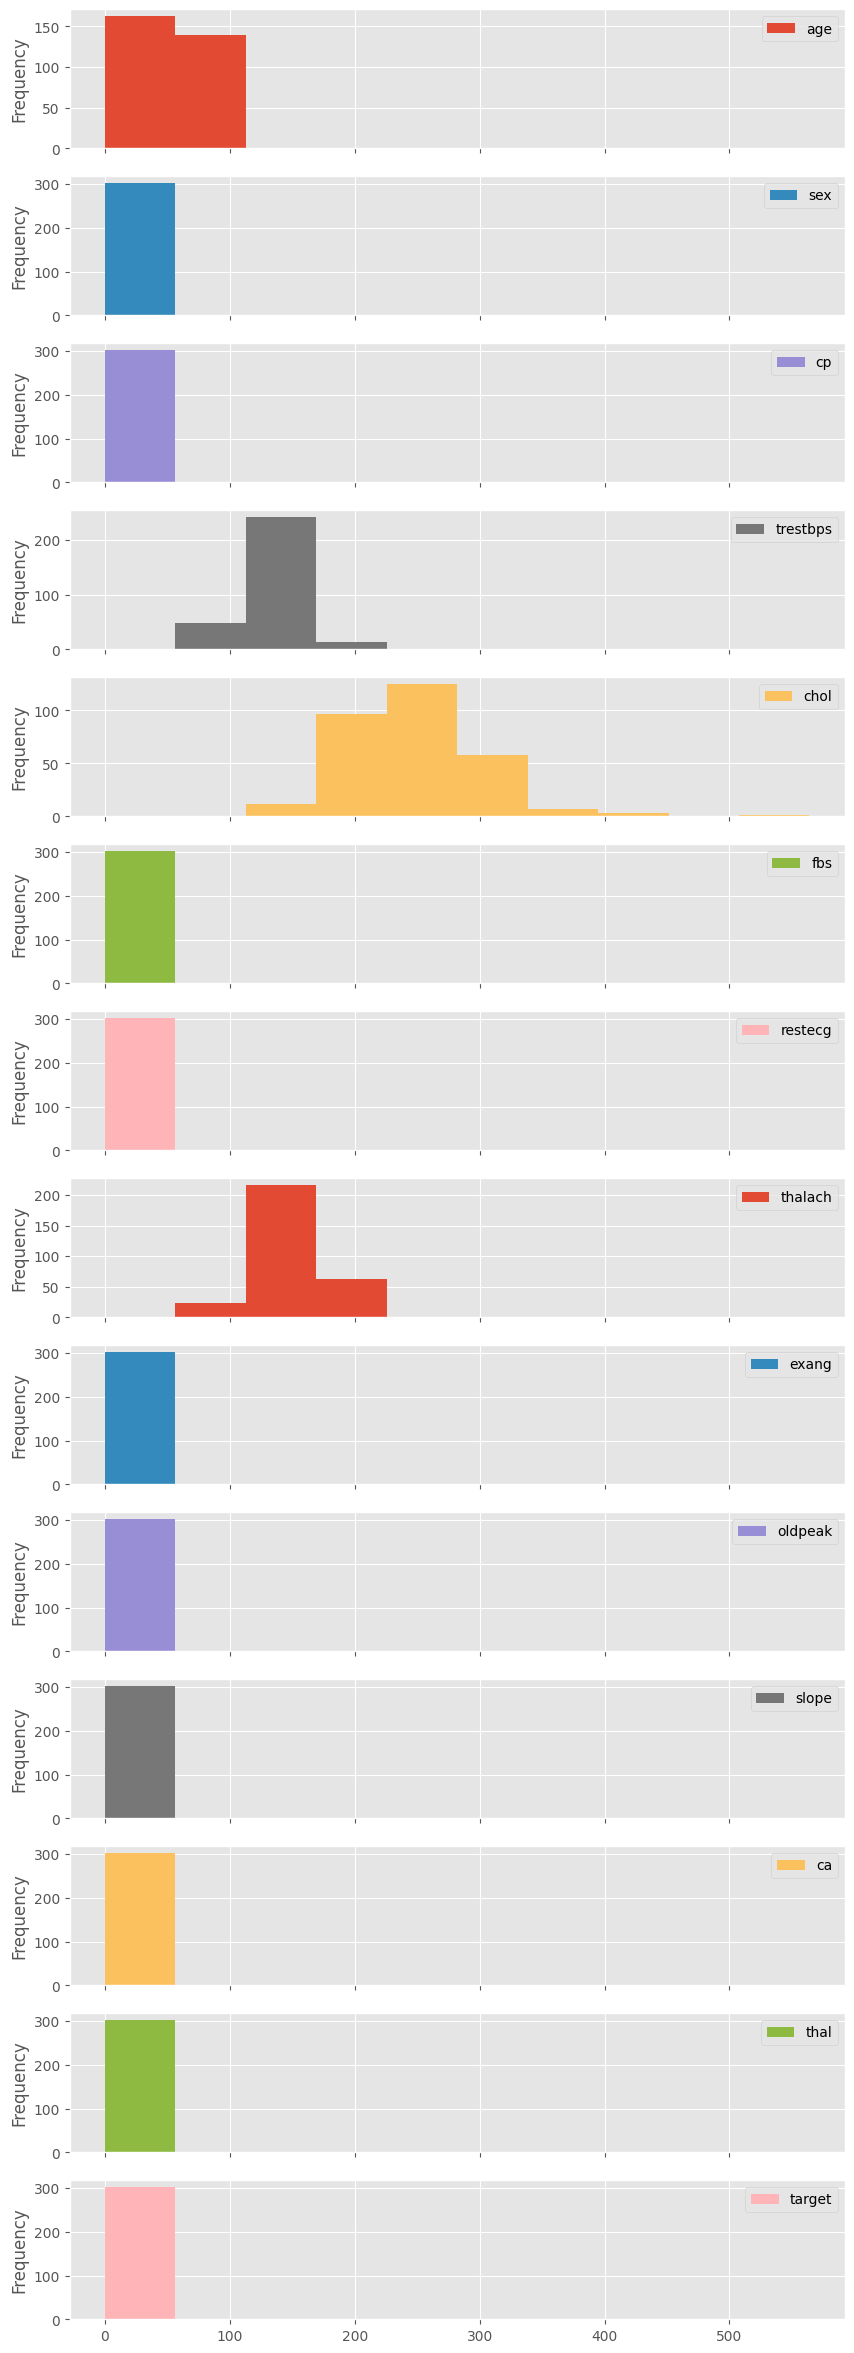

In [ ]:
heart_disease.plot.hist(figsize=(10, 30), subplots=True);

## 4. Plotting with pandas using the OO method 

For more complicated plots, you'll want to use the OO method.

In [ ]:
# Perform data analysis on patients over 50
over_50 = heart_disease[heart_disease["age"] > 50]
over_50

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,59,1,0,164,176,1,0,90,0,1.0,1,2,1,0
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


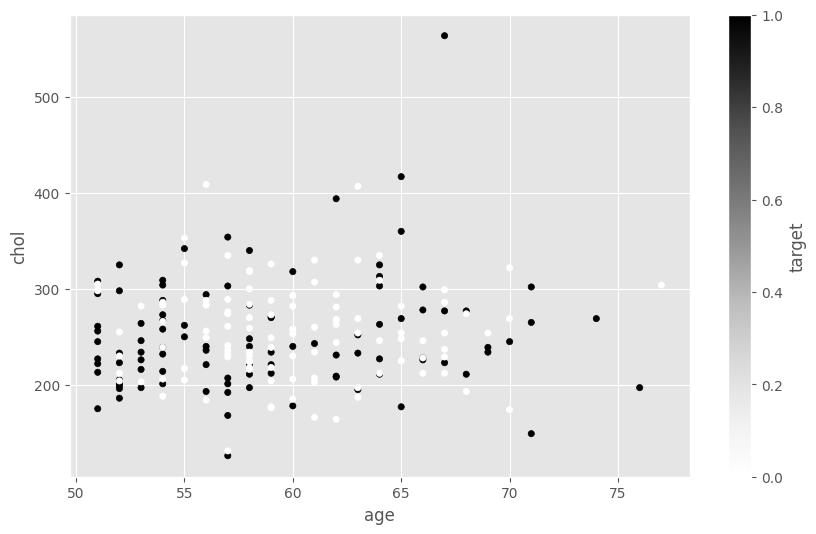

In [ ]:
over_50.plot(kind='scatter', 
             x='age', 
             y='chol', 
             c='target', 
             figsize=(10, 6));

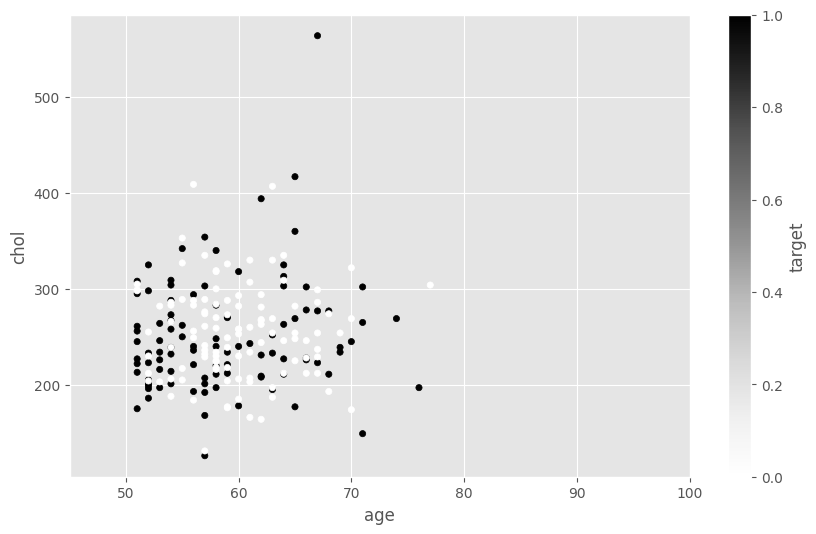

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
over_50.plot(kind='scatter', 
             x="age", 
             y="chol", 
             c='target', 
             ax=ax);
ax.set_xlim([45, 100]);

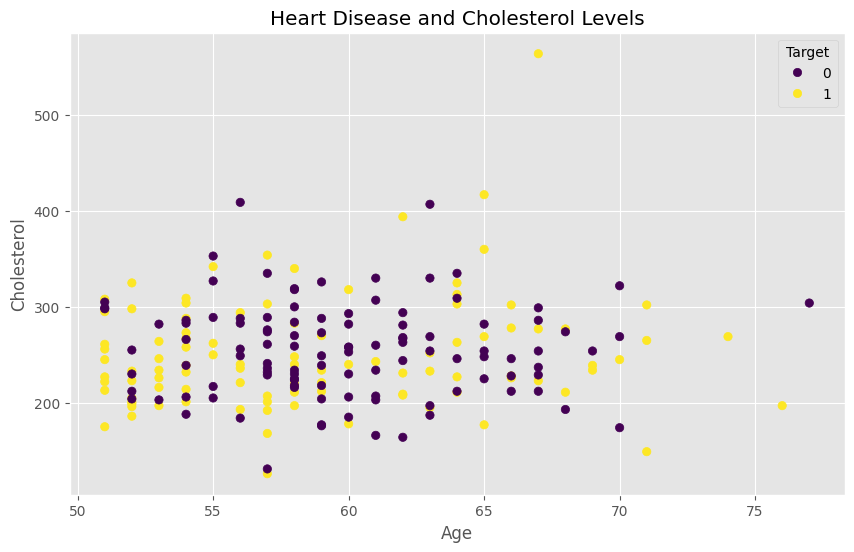

In [ ]:
# Make a bit more of a complicated plot

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data
scatter = ax.scatter(over_50["age"], 
                     over_50["chol"], 
                     c=over_50["target"])

# Customize the plot
ax.set(title="Heart Disease and Cholesterol Levels",
       xlabel="Age",
       ylabel="Cholesterol");
ax.legend(*scatter.legend_elements(), title="Target");

What if we wanted a horizontal line going across with the mean of `heart_disease["chol"]`?

https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.axes.Axes.axhline.html

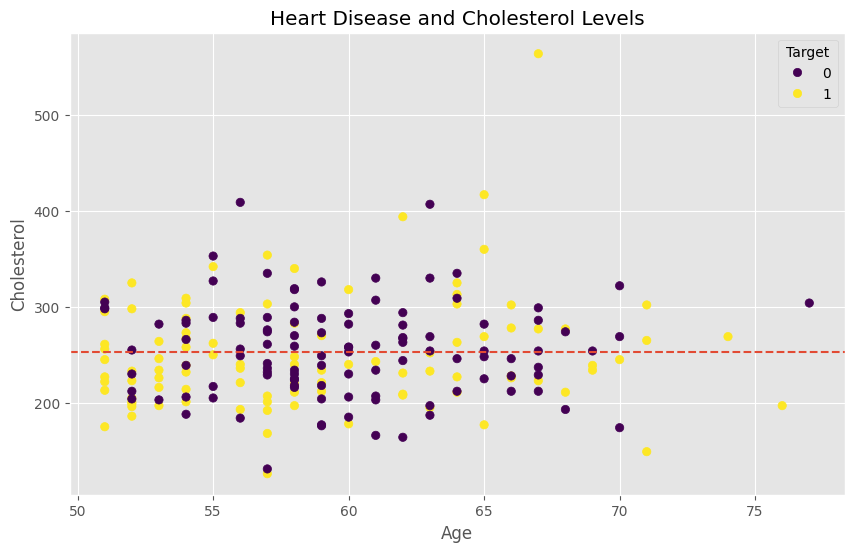

In [ ]:
# Make a bit more of a complicated plot

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data
scatter = ax.scatter(over_50["age"], 
                     over_50["chol"], 
                     c=over_50["target"])

# Customize the plot
ax.set(title="Heart Disease and Cholesterol Levels",
       xlabel="Age",
       ylabel="Cholesterol");
ax.legend(*scatter.legend_elements(), title="Target")

# Add a meanline
ax.axhline(over_50["chol"].mean(),
           linestyle="--");

### Adding another plot to existing styled one

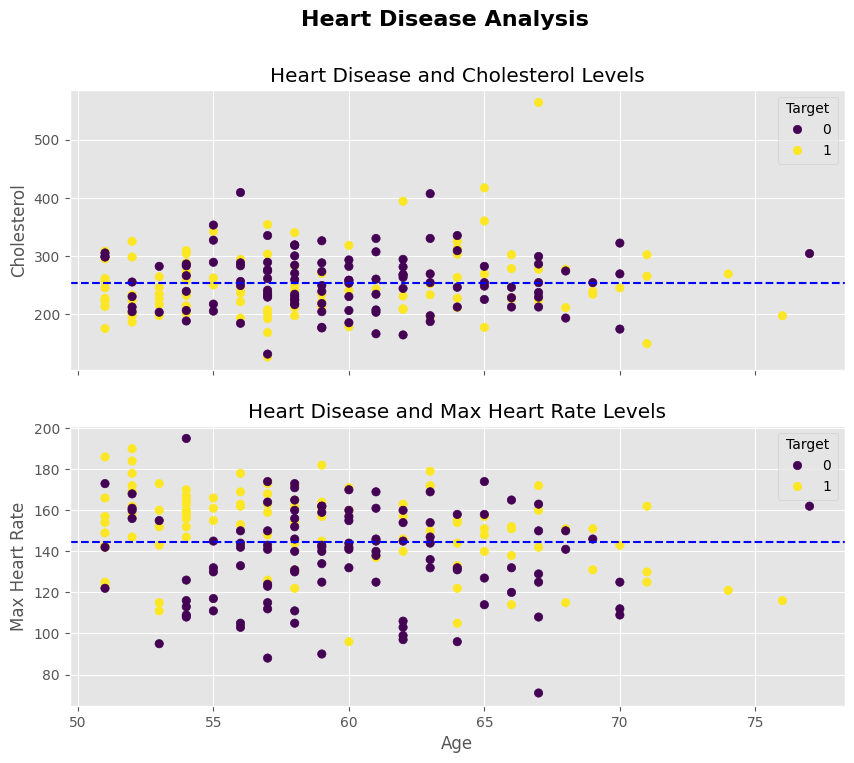

In [ ]:
# Setup plot (2 rows, 1 column)
fig, (ax0, ax1) = plt.subplots(nrows=2, # 2 rows
                               ncols=1, 
                               sharex=True, 
                               figsize=(10, 8))

# Add data for ax0
scatter = ax0.scatter(over_50["age"], 
                      over_50["chol"], 
                      c=over_50["target"])
# Customize ax0
ax0.set(title="Heart Disease and Cholesterol Levels",
        ylabel="Cholesterol")
ax0.legend(*scatter.legend_elements(), title="Target")

# Setup a mean line
ax0.axhline(y=over_50["chol"].mean(), 
            color='b', 
            linestyle='--', 
            label="Average")


# Add data for ax1
scatter = ax1.scatter(over_50["age"], 
                      over_50["thalach"], 
                      c=over_50["target"])

# Customize ax1
ax1.set(title="Heart Disease and Max Heart Rate Levels",
        xlabel="Age",
        ylabel="Max Heart Rate")
ax1.legend(*scatter.legend_elements(), title="Target")

# Setup a mean line
ax1.axhline(y=over_50["thalach"].mean(), 
            color='b', 
            linestyle='--', 
            label="Average")

# Title the figure
fig.suptitle('Heart Disease Analysis', fontsize=16, fontweight='bold');

## 5. Customizing your plots

This is where Matplotlib starts to feel powerful.

In this section we will work through several layers of customization:

- styles
- titles and axis labels
- legends
- colormaps
- axis limits
- ticks and tick labels


### Style

In [ ]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

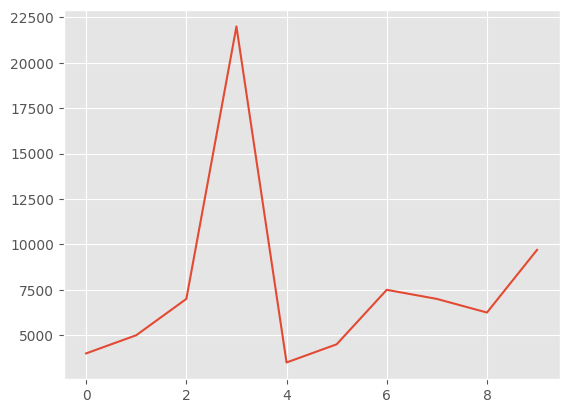

In [ ]:
# Plot before changing style
car_sales["Price"].plot();

In [ ]:
# Change the style... 
#plt.style.use('seaborn-whitegrid')

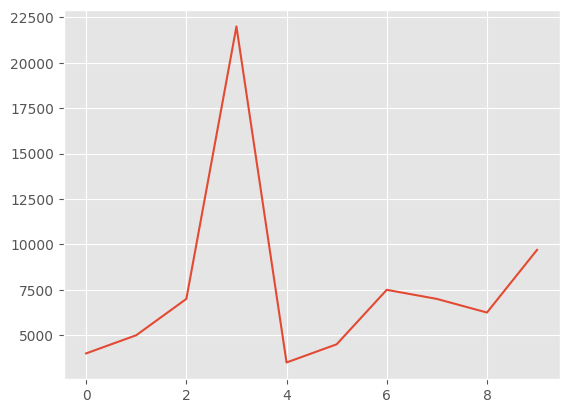

In [ ]:
car_sales["Price"].plot();

In [ ]:
#plt.style.use('seaborn')

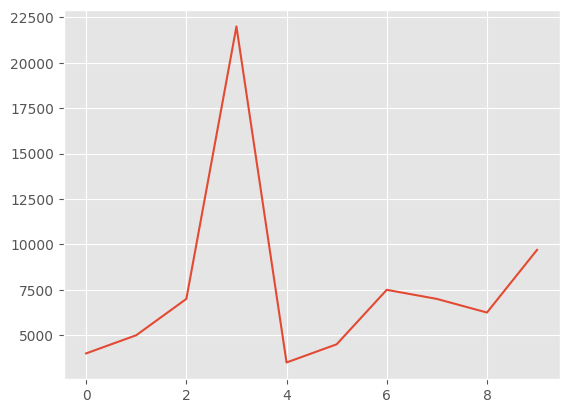

In [ ]:
car_sales["Price"].plot();

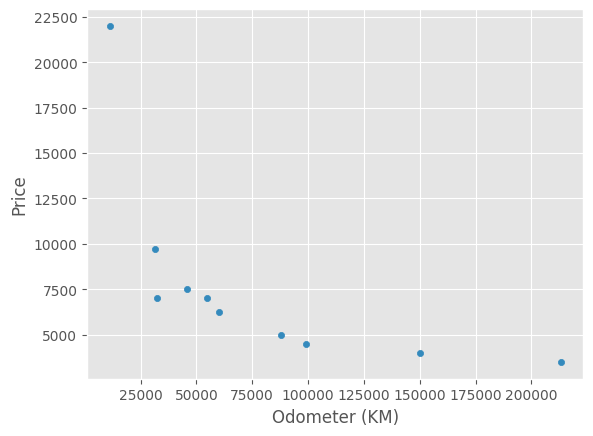

In [ ]:
car_sales.plot(x="Odometer (KM)", y="Price", kind="scatter");

In [ ]:
plt.style.use('ggplot')

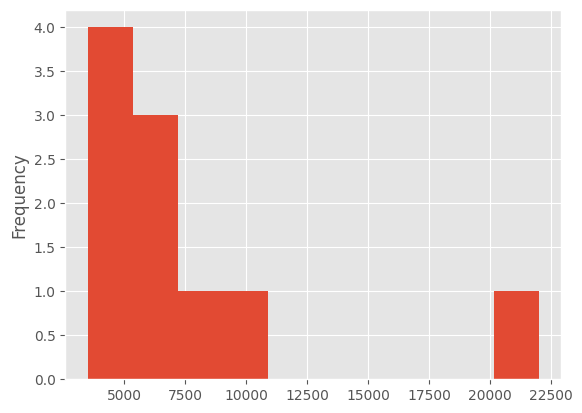

In [ ]:
car_sales["Price"].plot.hist();

### Labels and legends

Titles, axis labels, and legends are not decoration. They are part of the meaning of the chart.

A good beginner rule is:

- label your axes as soon as the values would otherwise be ambiguous
- prefer `label=...` inside the plotting call, then call `ax.legend()` afterwards
- use legends when multiple lines or marker groups appear in the same axes


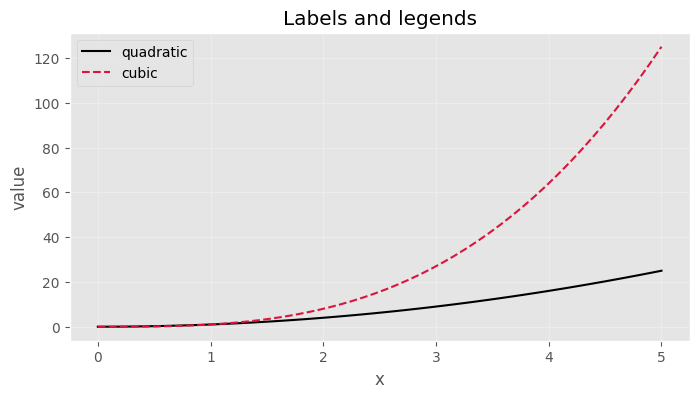

In [ ]:
legend_x = np.linspace(0, 5, 50)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(legend_x, legend_x**2, color='black', label='quadratic')
ax.plot(legend_x, legend_x**3, color='crimson', linestyle='--', label='cubic')
ax.set_title('Labels and legends')
ax.set_xlabel('x')
ax.set_ylabel('value')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.show()


### Changing the title, legend, axes 

In [ ]:
x = np.random.randn(10, 4)
x

array([[-3.35522756e-01, -2.24129057e-01, -4.06357025e-01,
         5.54899741e-01],
       [-6.99240449e-01,  1.56390824e+00,  8.27540683e-01,
        -5.89698411e-01],
       [-5.17688344e-01,  4.38975060e-01, -1.88782802e-01,
        -9.47426360e-01],
       [-3.15415775e-01, -2.41362681e+00, -2.46102571e-01,
         1.73133919e+00],
       [ 6.99392150e-01, -4.91257282e-01,  1.38930145e+00,
        -1.50185690e-01],
       [-5.61508027e-01,  1.26321378e+00,  2.04300650e+00,
         6.40515662e-01],
       [-5.61534616e-01,  6.71991504e-01,  1.13939270e+00,
        -7.47731125e-01],
       [ 1.53980113e+00,  4.56103368e-01, -2.10090310e-03,
        -2.08927044e-01],
       [ 1.00043797e+00, -4.37872798e-03, -2.69891297e-01,
         2.63633352e-01],
       [-8.96955817e-02, -7.42662389e-02, -3.47281198e-01,
         1.64529984e+00]])

In [ ]:
df = pd.DataFrame(x, columns=['a', 'b', 'c', 'd'])
df

,a,b,c,d
0,-0.335523,-0.224129,-0.406357,0.554900
1,-0.699240,1.563908,0.827541,-0.589698
2,-0.517688,0.438975,-0.188783,-0.947426
3,-0.315416,-2.413627,-0.246103,1.731339
4,0.699392,-0.491257,1.389301,-0.150186
5,-0.561508,1.263214,2.043006,0.640516
6,-0.561535,0.671992,1.139393,-0.747731
7,1.539801,0.456103,-0.002101,-0.208927
8,1.000438,-0.004379,-0.269891,0.263633
9,-0.089696,-0.074266,-0.347281,1.645300


matplotlib.axes._axes.Axes

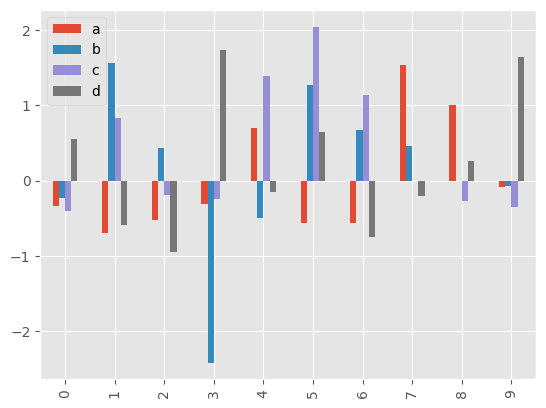

In [ ]:
ax = df.plot(kind='bar')
type(ax)

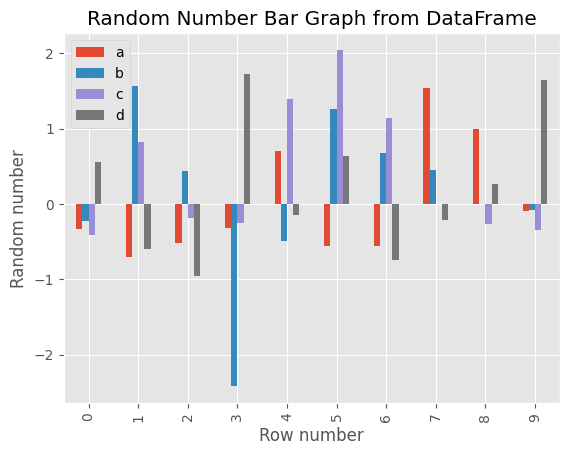

In [ ]:
ax = df.plot(kind='bar')
ax.set(title="Random Number Bar Graph from DataFrame", 
       xlabel="Row number", 
       ylabel="Random number")
ax.legend().set_visible(True)

### Changing the cmap

In [ ]:
#plt.style.use('seaborn-whitegrid')

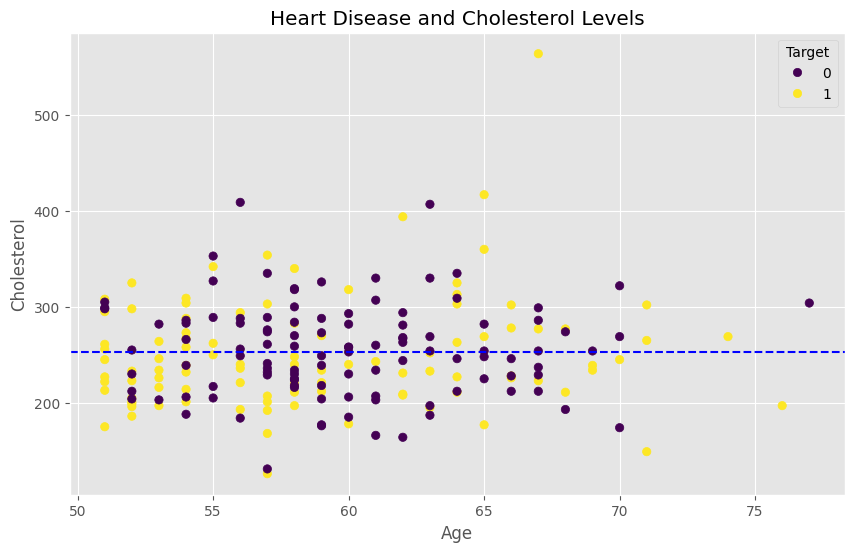

In [ ]:
# No cmap change
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(over_50["age"], 
                     over_50["chol"], 
                     c=over_50["target"])
ax.set(title="Heart Disease and Cholesterol Levels",
       xlabel="Age",
       ylabel="Cholesterol");
ax.axhline(y=over_50["chol"].mean(), 
           c='b', 
           linestyle='--', 
           label="Average");
ax.legend(*scatter.legend_elements(), title="Target");

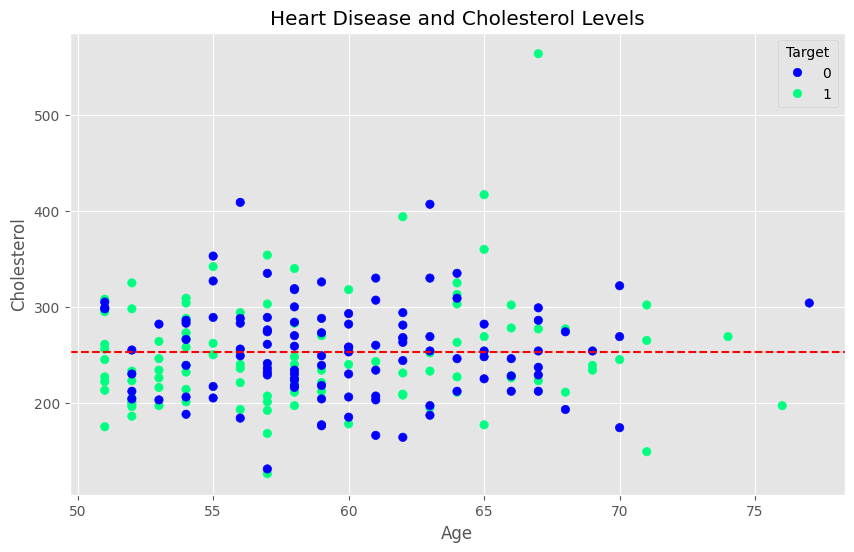

In [ ]:
# Change cmap and horizontal line to be a different colour
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(over_50["age"], 
                     over_50["chol"], 
                     c=over_50["target"], 
                     cmap="winter")
ax.set(title="Heart Disease and Cholesterol Levels",
       xlabel="Age",
       ylabel="Cholesterol")
ax.axhline(y=over_50["chol"].mean(), 
           color='r', 
           linestyle='--', 
           label="Average");
ax.legend(*scatter.legend_elements(), title="Target");

### Changing the xlim & ylim

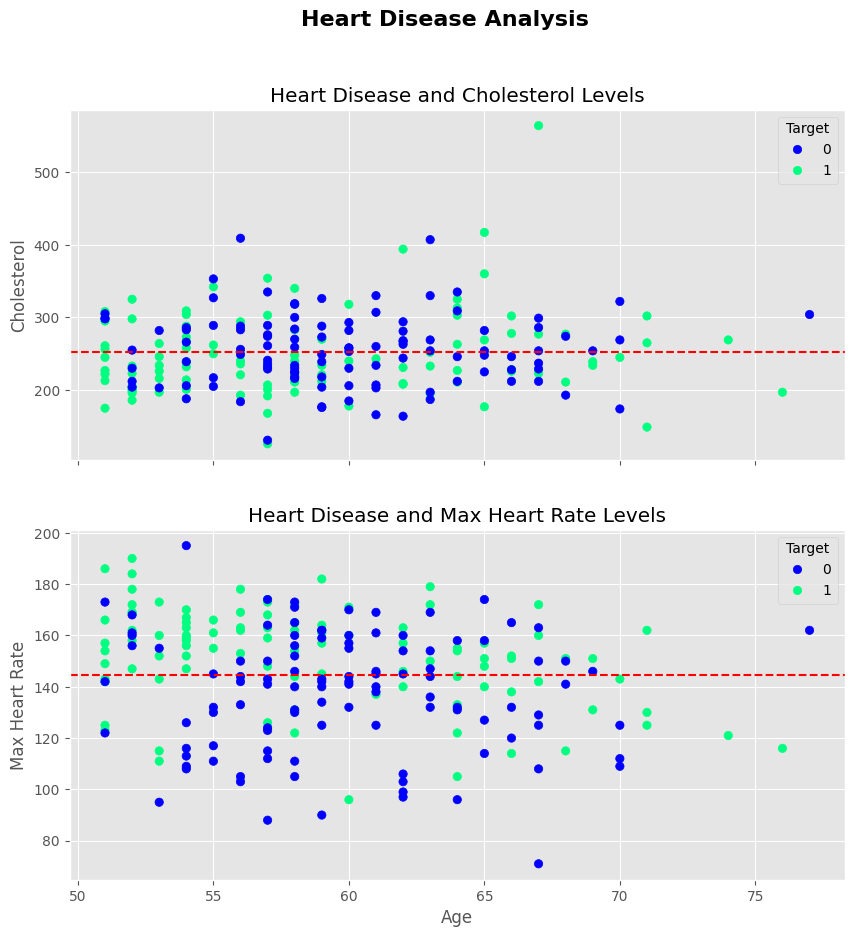

In [ ]:
## Before the change (we've had color updates)

fig, (ax0, ax1) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 10))
scatter = ax0.scatter(over_50["age"], 
                      over_50["chol"], 
                      c=over_50["target"],
                      cmap='winter')
ax0.set(title="Heart Disease and Cholesterol Levels",
        ylabel="Cholesterol")

# Setup a mean line
ax0.axhline(y=over_50["chol"].mean(), 
            color='r', 
            linestyle='--', 
            label="Average");
ax0.legend(*scatter.legend_elements(), title="Target")

# Axis 1, 1 (row 1, column 1)
scatter = ax1.scatter(over_50["age"], 
                      over_50["thalach"], 
                      c=over_50["target"],
                      cmap='winter')
ax1.set(title="Heart Disease and Max Heart Rate Levels",
        xlabel="Age",
        ylabel="Max Heart Rate")

# Setup a mean line
ax1.axhline(y=over_50["thalach"].mean(), 
            color='r', 
            linestyle='--', 
            label="Average");
ax1.legend(*scatter.legend_elements(), title="Target")

# Title the figure
fig.suptitle('Heart Disease Analysis', fontsize=16, fontweight='bold');

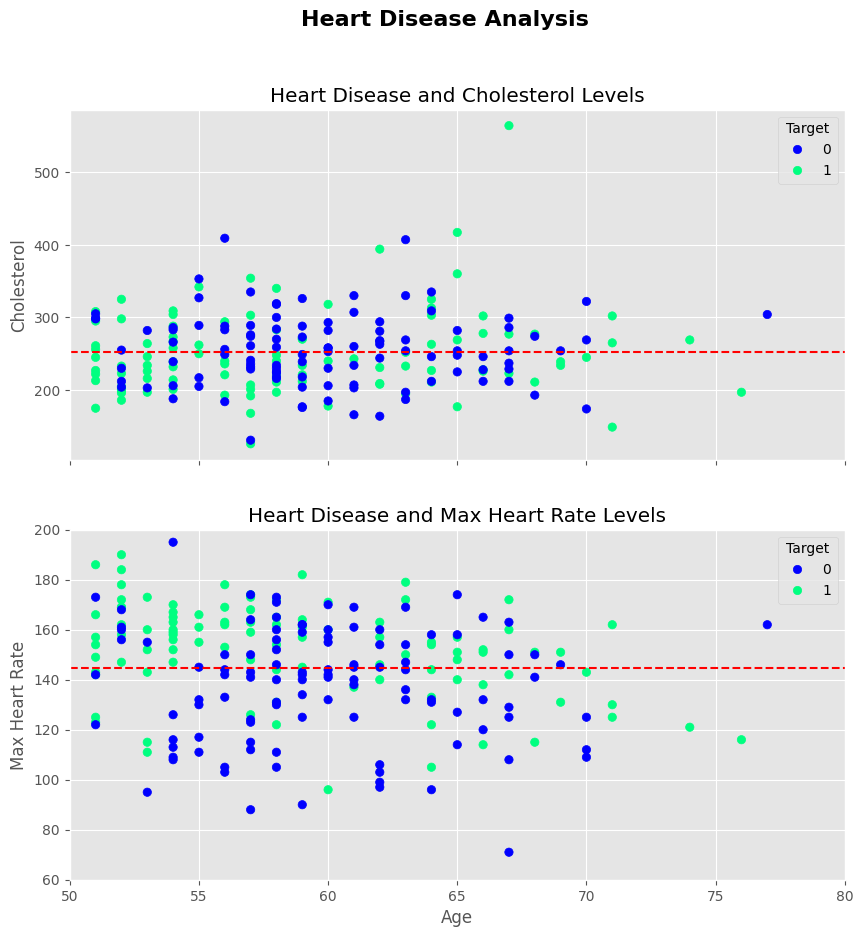

In [ ]:
## After adding in different x & y limitations

fig, (ax0, ax1) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 10))
scatter = ax0.scatter(over_50["age"], 
                      over_50["chol"], 
                      c=over_50["target"],
                      cmap='winter')
ax0.set(title="Heart Disease and Cholesterol Levels",
        ylabel="Cholesterol")

# Set the x axis
ax0.set_xlim([50, 80])

# Setup a mean line
ax0.axhline(y=over_50["chol"].mean(), 
            color='r', 
            linestyle='--', 
            label="Average");
ax0.legend(*scatter.legend_elements(), title="Target")

# Axis 1, 1 (row 1, column 1)
scatter = ax1.scatter(over_50["age"], 
                      over_50["thalach"], 
                      c=over_50["target"],
                      cmap='winter')
ax1.set(title="Heart Disease and Max Heart Rate Levels",
        xlabel="Age",
        ylabel="Max Heart Rate")

# Set the y axis
ax1.set_ylim([60, 200])

# Setup a mean line
ax1.axhline(y=over_50["thalach"].mean(), 
            color='r', 
            linestyle='--', 
            label="Average");
ax1.legend(*scatter.legend_elements(), title="Target")

# Title the figure
fig.suptitle('Heart Disease Analysis', fontsize=16, fontweight='bold');

### Ticks verstehen und anpassen

Ticks are the small marks and labels along the axes. They control how easy it is to read values from the chart.

We will go through four connected ideas:

1. automatic ticks
2. manually setting tick positions
3. generating evenly spaced ticks with `np.linspace()`
4. customizing tick labels


#### 1. Automatic ticks

By default, Matplotlib chooses tick positions for you based on the data range and figure size.


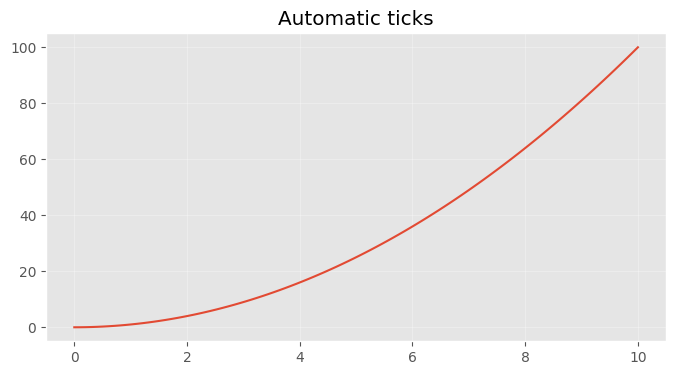

Automatically chosen x-ticks:
[-2.  0.  2.  4.  6.  8. 10. 12.]

Automatically chosen y-ticks:
[-20.   0.  20.  40.  60.  80. 100. 120.]


In [ ]:
auto_x = np.linspace(0, 10, 100)
auto_y = auto_x**2

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(auto_x, auto_y)
ax.set_title('Automatic ticks')
ax.grid(True, alpha=0.3)
plt.show()

print('Automatically chosen x-ticks:')
print(ax.get_xticks())
print('\nAutomatically chosen y-ticks:')
print(ax.get_yticks())


#### 2. Manual ticks

When the automatic choice is not the clearest one, you can specify the tick positions yourself with `set_xticks()` and `set_yticks()`.


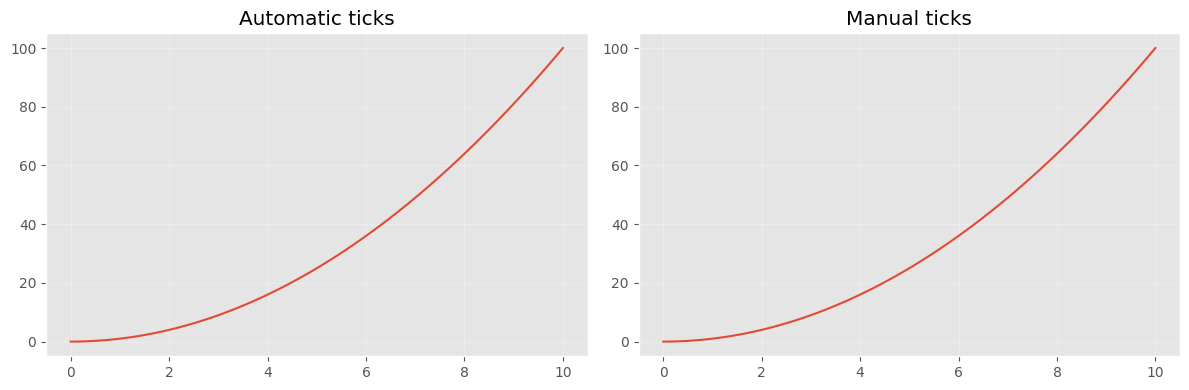

In [ ]:
manual_x = np.linspace(0, 10, 100)
manual_y = manual_x**2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(manual_x, manual_y)
ax1.set_title('Automatic ticks')
ax1.grid(True, alpha=0.3)

ax2.plot(manual_x, manual_y)
ax2.set_xticks([0, 2, 4, 6, 8, 10])
ax2.set_yticks([0, 20, 40, 60, 80, 100])
ax2.set_title('Manual ticks')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#### 3. Ticks with `np.linspace()`

`np.linspace()` is perfect when you want evenly spaced ticks without writing every value by hand.


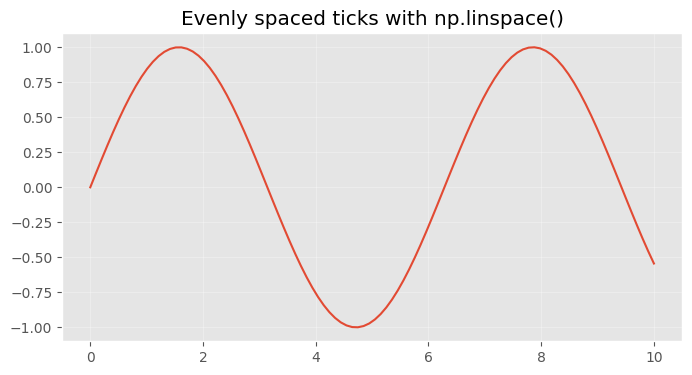

Tick positions created with np.linspace(0, 10, 6):
[ 0.  2.  4.  6.  8. 10.]


In [ ]:
linspace_x = np.linspace(0, 10, 100)
linspace_y = np.sin(linspace_x)
linspace_ticks = np.linspace(0, 10, 6)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(linspace_x, linspace_y)
ax.set_xticks(linspace_ticks)
ax.set_title('Evenly spaced ticks with np.linspace()')
ax.grid(True, alpha=0.3)
plt.show()

print('Tick positions created with np.linspace(0, 10, 6):')
print(linspace_ticks)


#### 4. Custom tick labels

After setting tick positions, you can replace the labels with percentages, currencies, categories, or other domain-specific text.


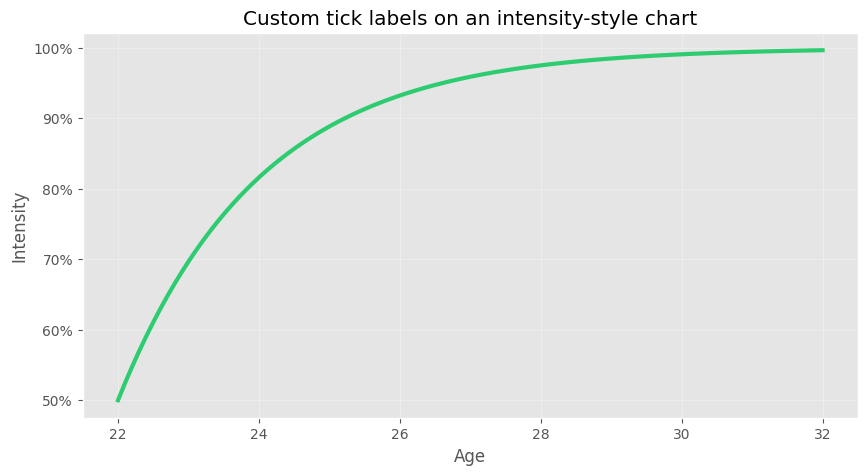

In [ ]:
intensity_x = np.linspace(22, 32, 100)
intensity_y = 0.5 + 0.5 * (1 - np.exp(-0.5 * (intensity_x - 22)))

y_ticks = np.linspace(0.5, 1.0, 6)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(intensity_x, intensity_y, color='#2ecc71', linewidth=3)
ax.set_xticks(np.linspace(22, 32, 6))
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{int(t * 100)}%' for t in y_ticks])
ax.set_title('Custom tick labels on an intensity-style chart')
ax.set_xlabel('Age')
ax.set_ylabel('Intensity')
ax.grid(True, alpha=0.3)
plt.show()


## 6. Saving plots

Use `fig.savefig()` to export a figure to disk.

Common patterns:

- save after you finish customizing the figure
- use descriptive filenames
- keep the `fig` object around when you know you want to export

If you repeat the same plotting workflow often, it can be worth wrapping the process in a function.


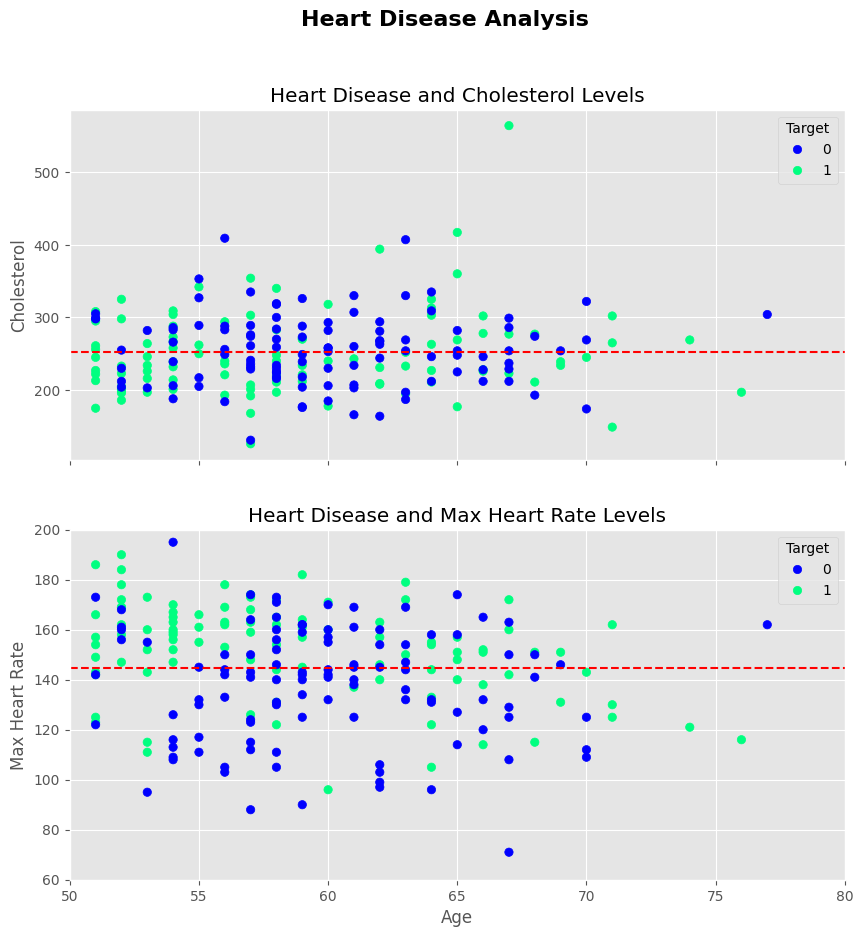

In [ ]:
# Axis 0, 1 (row 0, column 0)
fig, (ax0, ax1) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 10))
scatter = ax0.scatter(over_50["age"], 
                      over_50["chol"], 
                      c=over_50["target"],
                      cmap='winter')
ax0.set(title="Heart Disease and Cholesterol Levels",
        ylabel="Cholesterol")

# Set the x axis
ax0.set_xlim([50, 80])

# Setup a mean line
ax0.axhline(y=over_50["chol"].mean(), 
            color='r', 
            linestyle='--', 
            label="Average");
ax0.legend(*scatter.legend_elements(), title="Target")

# Axis 1, 1 (row 1, column 1)
scatter = ax1.scatter(over_50["age"], 
                      over_50["thalach"], 
                      c=over_50["target"],
                      cmap='winter')
ax1.set(title="Heart Disease and Max Heart Rate Levels",
        xlabel="Age",
        ylabel="Max Heart Rate")

# Set the y axis
ax1.set_ylim([60, 200])

# Setup a mean line
ax1.axhline(y=over_50["thalach"].mean(), 
            color='r', 
            linestyle='--', 
            label="Average");
ax1.legend(*scatter.legend_elements(), title="Target")

# Title the figure
fig.suptitle('Heart Disease Analysis', fontsize=16, fontweight='bold');

In [ ]:
# Check the supported filetypes
fig.canvas.get_supported_filetypes()

{'eps': 'Encapsulated Postscript',
 'jpg': 'Joint Photographic Experts Group',
 'jpeg': 'Joint Photographic Experts Group',
 'pdf': 'Portable Document Format',
 'pgf': 'PGF code for LaTeX',
 'png': 'Portable Network Graphics',
 'ps': 'Postscript',
 'raw': 'Raw RGBA bitmap',
 'rgba': 'Raw RGBA bitmap',
 'svg': 'Scalable Vector Graphics',
 'svgz': 'Scalable Vector Graphics',
 'tif': 'Tagged Image File Format',
 'tiff': 'Tagged Image File Format',
 'webp': 'WebP Image Format'}

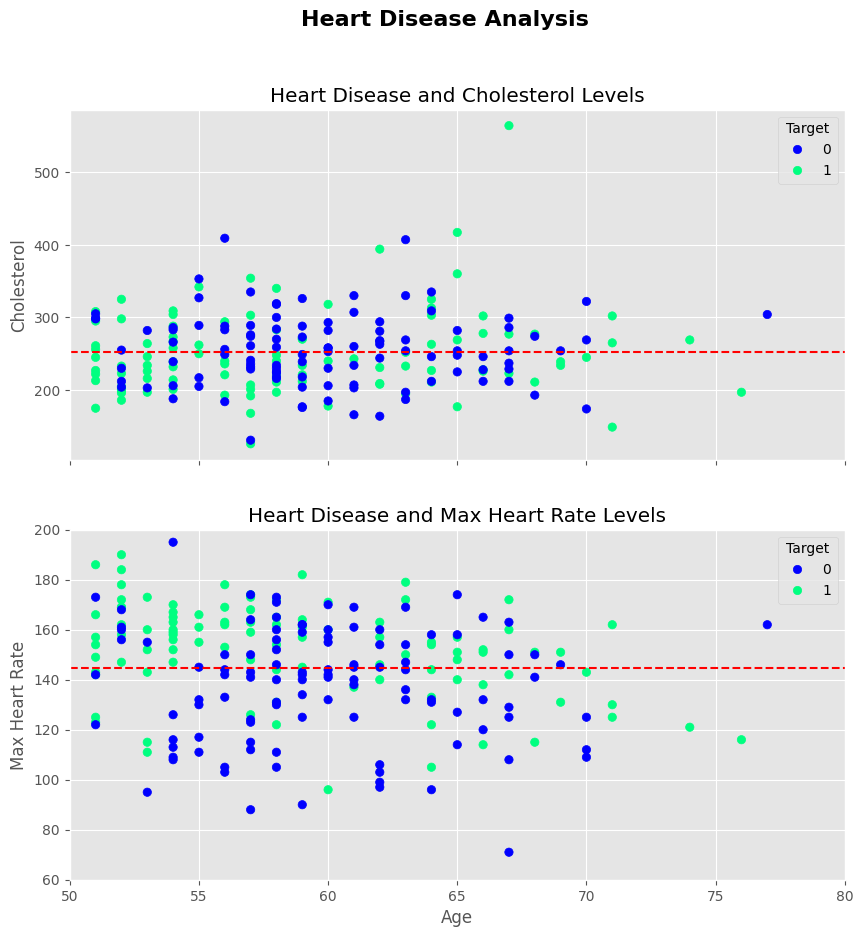

In [ ]:
fig

In [ ]:
# Save the file
fig.savefig("../images/heart-disease-analysis.png")

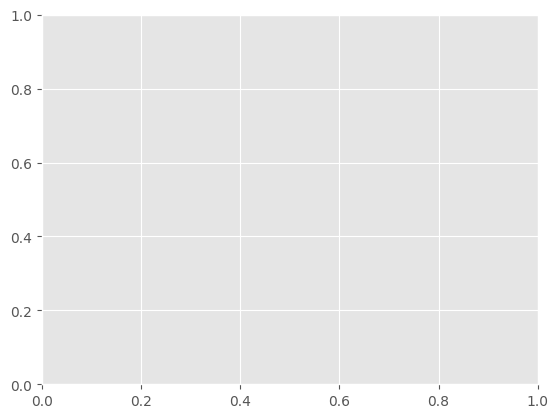

In [ ]:
# Resets figure
fig, ax = plt.subplots()

In [ ]:
# Potential function

def plotting_workflow(data):
    # 1. Manipulate data
    
    # 2. Create plot
    
    # 3. Plot data
    
    # 4. Customize plot
    
    # 5. Save plot
    
    # 6. Return plot
    
    return plot

## 7. Where to go next

This notebook is meant to be the bridge notebook. If you want to continue in a clean sequence, use this order:

1. This notebook for the practical overview and the main plotting workflow
2. [matplotlib_fundamentals_explained.ipynb](matplotlib_fundamentals_explained.ipynb) for a deeper dive into `np.linspace()`, ticks, figure/axes logic, and arrays vs. lists
3. [Kopie_von_Intro_to_matplotlib.ipynb](Kopie_von_Intro_to_matplotlib.ipynb) for a broader Matplotlib reference notebook with more examples, anatomy, legends, styling, and advanced axis control
4. [matplotlib_seaborn_intro.ipynb](../lessons/lesson-2/notebooks/matplotlib_seaborn_intro.ipynb) for the transition from Matplotlib fundamentals into Seaborn and more statistical plotting

Natural follow-up notebook ideas from this sequence would be:

- plot selection patterns: when to use line vs. scatter vs. bar vs. histogram
- axis design: ticks, limits, scales, and annotation patterns
- pandas vs. seaborn vs. pure Matplotlib: when each workflow is the right tool
